# Plasmid functional niche across the WAHL pH–salinity gradient

In [1]:
import os, re, glob, difflib, warnings
import numpy as np
import pandas as pd

#abundance 
PLASMID_DIR   = "/Users/skoog/Desktop/sensitivity_analysis_plasmids"
COVERM_FILE   = "coverm_plasmid_mcf0.tsv"
MCF           = 0.50

#gene calls 
GENOMAD_DIRS  = {"dry": "/Users/skoog/Desktop/WATL24_metagenomics_viromics/genomad_plasmid_output_files",
                 "wet": "/Users/skoog/Desktop/WATL22_metagenomics_viromics/genomad_plasmid_output_files"}
GENE_GLOBS    = ["*plasmid*gene*.tsv", "*_genes*.tsv", "*gene*.tsv"]
SUMMARY_GLOBS = ["*plasmid_summary*.tsv", "*summary*.tsv"]
PREBUILT_GENES = "/Users/skoog/Desktop/combined_wet_dry_plasmid_df_classified_genes_df_final.csv"

#classification
STRESS_SOURCE = "/Users/skoog/Desktop/osmotic_stressv2.xlsx"
STRESS_XLSX   = "/Users/skoog/Desktop/stress_classification.xlsx"
FUNC_XLSX     = "/Users/skoog/Desktop/unique_annotation_descriptions_combined_wet_dry_plasmid_df_classified.xlsx"
FUNC_COL      = "Category_3"

EXCLUDE_ANNOTATIONS = {"rusticyanin": "acidophile energy metabolism, not a stress response"}
CAT3_RULE = lambda s: ("Osmotic Stress Response"
                       if "osmot" in str(s).lower() and "protect" in str(s).lower()
                       else str(s).strip())

META_XLSX = "/Users/skoog/Desktop/WATL22_WATL24_merged_salinity_pH_aw.xlsx"
OUTDIR    = "/Users/skoog/Desktop"

#contig IDs: CoverM prefixes WATL24 contigs, geNomad does not 
CONTIG_PREFIX = r"^WATL2\d_"
norm_contig = lambda s: re.sub(CONTIG_PREFIX, "", str(s).strip())

# samples and units 
SAMPLE_ALIASES = {}
DROP_UNMATCHED = True
ENV_REQUIRED   = ["pH", "Salinity"]
LAKE_KEY_MODE  = "name_season"          

#  category screen: none applied; support and detectability are reported instead
MIN_GENES         = 0
MIN_CONTIGS       = 0
MIN_LAKES_PRESENT = 1

#CLR 
CLR_FRAC          = 0.65
CLR_MAX_REPL_MASS = 0.05
CLR_FRAC_SWEEP    = [0.30, 0.65, 1.00]

CATEGORY_COL         = "Category"
INCLUDE_UNCLASSIFIED = True
N_PERM               = 999
N_BOOT               = 2000
SEED                 = 42

# figures 
PANEL_UNIT     = "genes"                                 
KDE_PANEL_CATS = ["Acid Stress", "General Stress",
                  "Ectoine / Hydroxyectoine", "Ectoine Catabolism",
                  "Trehalose Biosynthesis", "Trehalose Catabolism"]
KDE_TITLES     = {}
NCOL           = 2
BUBBLE_MIN, BUBBLE_MAX, BUBBLE_GAMMA = 5, 150, 1.6
SHOW_CLUSTERS  = True

os.makedirs(OUTDIR, exist_ok=True)
rng = np.random.default_rng(SEED)
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
warnings.filterwarnings("ignore", category=RuntimeWarning)

def read_sheet(xlsx):
    """Read a spreadsheet, dropping empty padding columns."""
    t = pd.read_excel(xlsx)
    t.columns = t.columns.astype(str).str.strip()
    return t.loc[:, ~t.columns.str.startswith("Unnamed")].dropna(axis=1, how="all")

norm_key = lambda s: s.astype(str).str.strip().str.lower()

In [2]:
INPUTS = [("CoverM abundance", os.path.join(PLASMID_DIR, "**", COVERM_FILE), "glob"),
          ("geNomad dry",       GENOMAD_DIRS["dry"], "dir"),
          ("geNomad wet",       GENOMAD_DIRS["wet"], "dir"),
          ("stress source",     STRESS_SOURCE, "file"),
          ("functional class.", FUNC_XLSX, "file"),
          ("metadata",          META_XLSX, "file"),
          ("prebuilt genes",    PREBUILT_GENES, "file")]



In [3]:
#Stress classification

In [3]:
src = read_sheet(STRESS_SOURCE)
assert {"annotation_description", "Category", "Category_2"} <= set(src.columns), list(src.columns)

drop = norm_key(src["annotation_description"]).isin(EXCLUDE_ANNOTATIONS)
stress = src[~drop].copy()

stress["Category_3"] = stress["Category_2"].map(CAT3_RULE)

for c in ["Category", "Category_2", "Category_3"]:
    v = stress[c].dropna().astype(str).str.strip()
    dup = v.groupby(v.str.lower()).nunique()
    assert (dup <= 1).all(), f"case variants in {c}: " \
        f"{[sorted(v[v.str.lower() == k].unique()) for k in dup[dup > 1].index]}"

stress.to_excel(STRESS_XLSX, index=False, engine="openpyxl")
chk = read_sheet(STRESS_XLSX)
assert len(chk) == len(stress) and "Category_3" in chk.columns

print(f"\nwrote {os.path.basename(STRESS_XLSX)}: {len(chk)} annotations, "
      f"{chk['Category'].nunique()} / {chk['Category_2'].nunique()} / "
      f"{chk['Category_3'].nunique()} categories")
print(chk.groupby(["Category_3", "Category_2"]).size().to_string())

FIG_A_XLSX, FIG_A_COL, FIG_A_FILTER = FUNC_XLSX, FUNC_COL, None
FIG_B_XLSX, FIG_B_COL, FIG_B_FILTER = STRESS_XLSX, "Category_3", None
FIG_C_XLSX, FIG_C_COL, FIG_C_FILTER = STRESS_XLSX, "Category", ("Category_3", "Osmotic Stress Response")


wrote stress_classification.xlsx: 54 annotations, 14 / 4 / 3 categories
Category_3               Category_2                
Acid Stress Response     Acid Stress Response           1
General Stress Response  General Stress Response       11
Osmotic Stress Response  Osmotic Stress Response       29
                         Osmotprotectant Metabolism    12


In [5]:
#Plasmid abundance

In [4]:
hits = glob.glob(os.path.join(PLASMID_DIR, "**", COVERM_FILE), recursive=True)
assert hits, f"{COVERM_FILE} not found under {PLASMID_DIR}"
MCF0 = sorted(hits, key=len)[0]

STRIP = [".sorted", "_map_sorted_plasmid", "_filt", "_qc"]

def load_coverm(path):
    d = pd.read_csv(path, sep="\t")
    cid = d.columns[0]
    rp = {c[:-5]: c for c in d.columns if c.endswith(" RPKM")}
    cf = {c[:-17]: c for c in d.columns if c.endswith(" Covered Fraction")}
    out = []

    for s in sorted(set(rp) & set(cf)):
        nm = s
        for suf in STRIP:
            if nm.endswith(suf):
                nm = nm[:-len(suf)]

        out.append(pd.DataFrame({
            "sample": nm,
            "seq_name": d[cid].astype(str).values,
            "RPKM": pd.to_numeric(d[rp[s]], errors="coerce").values,
            "cf": pd.to_numeric(d[cf[s]], errors="coerce").values
        }))

    return pd.concat(out, ignore_index=True).dropna(subset=["RPKM", "cf"])

cov = load_coverm(MCF0)

cov["seq_name"] = (
    cov["seq_name"]
    .astype(str)
    .str.split("|")
    .str[-1]
    .str.strip()
    .map(norm_contig)
)

REFERENCE_CONTIGS = set(cov["seq_name"])

cov = cov[(cov["cf"] >= MCF) & (cov["RPKM"] > 0)].copy()

In [5]:
#Gene table and stress annotation

In [6]:
def find_gene_tsv(season):
    d = GENOMAD_DIRS[season]
    if os.path.isdir(d):
        for pat in GENE_GLOBS:
            c = sorted(glob.glob(os.path.join(d, pat)), key=len)
            if c:
                return c[0]
    return None


def load_genomad(path, season):
    g = pd.read_csv(path, sep="\t", low_memory=False)
    g["seq_name"] = g["gene"].astype(str).str.rsplit("_", n=1).str[0].str.strip()
    g["season"] = season
    keep = [c for c in ["gene", "seq_name", "season", "annotation_description",
                        "conjugation_genes", "amr_genes"] if c in g.columns]
    return g[keep]


def find_summary(season):
    d = GENOMAD_DIRS[season]
    if os.path.isdir(d):
        for pat in SUMMARY_GLOBS:
            c = sorted(glob.glob(os.path.join(d, pat)), key=len)
            if c:
                return c[0]
    return None


def attach_summary(g, season):
    """Merge conjugation_genes / amr_genes from the plasmid summary."""
    if {"conjugation_genes", "amr_genes"} <= set(g.columns):
        return g

    p = find_summary(season)
    if p is None:
        return g

    s = pd.read_csv(p, sep="\t", low_memory=False)
    s.columns = s.columns.astype(str).str.strip()

    cols = [c for c in ["seq_name", "conjugation_genes", "amr_genes"] if c in s.columns]
    if len(cols) < 2:
        return g

    s["seq_name"] = s["seq_name"].astype(str).str.strip()
    return g.merge(s[cols].drop_duplicates("seq_name"), on="seq_name", how="left")


tsv = {s: find_gene_tsv(s) for s in ("dry", "wet")}

if all(tsv.values()):
    allgenes = pd.concat([
        attach_summary(load_genomad(tsv["wet"], "wet"), "wet"),
        attach_summary(load_genomad(tsv["dry"], "dry"), "dry")
    ], ignore_index=True)

    SOURCE = "geNomad gene tables"

else:
    for s, p in tsv.items():
        if p is None:
            print(f"!! no geNomad gene table for '{s}' in {GENOMAD_DIRS[s]}")
            if os.path.isdir(GENOMAD_DIRS[s]):
                for f in sorted(os.listdir(GENOMAD_DIRS[s]))[:20]:
                    print("     ", f)

    assert os.path.exists(PREBUILT_GENES), "no gene table available"

    _p = pd.read_csv(PREBUILT_GENES, low_memory=False)
    allgenes = _p[[c for c in [
        "gene", "seq_name", "season", "annotation_description",
        "conjugation_genes", "amr_genes"
    ] if c in _p.columns]]

    SOURCE = "prebuilt gene table"
    print(f"!! falling back to {os.path.basename(PREBUILT_GENES)}")


allgenes = allgenes.drop_duplicates("gene")
allgenes["seq_name"] = allgenes["seq_name"].astype(str).str.strip().map(norm_contig)

ns = allgenes.groupby("seq_name")["season"].nunique()
assert (ns <= 1).all(), (
    f"{int((ns > 1).sum())} contig IDs in both seasons - "
    "assembler-local IDs colliding, prefix by source"
)

cls = read_sheet(STRESS_XLSX)
cls["_key"] = norm_key(cls["annotation_description"])

cls_small = (
    cls[["_key", CATEGORY_COL]]
    .dropna(subset=[CATEGORY_COL])
    .drop_duplicates("_key")
)

allgenes["_key"] = norm_key(allgenes["annotation_description"])

allgenes = (
    allgenes.merge(cls_small, on="_key", how="left")
    .drop(columns="_key")
    .rename(columns={CATEGORY_COL: "Category"})
)

n_cls = int(allgenes["Category"].notna().sum())

print(f"\nsource: {SOURCE} | {len(allgenes):,} genes | {n_cls:,} classified")
print(allgenes["Category"].value_counts().to_string())


source: geNomad gene tables | 201,832 genes | 1,044 classified
Category
Choline/Glycine Betaine compatible solute regulation                260
Na⁺, K⁺, and proton antiporters / transporters (ion homeostasis)    208
General Stress Response                                             165
Ectoine Catabolism / Osmolyte Recycling                             153
Ectoine / Hydroxyectoine Biosynthesis/ Import                       130
Acid Stress Response                                                 28
Ca²⁺ antiporters involved in ionic/osmotic balance                   27
Osmotic Stress Regulation                                            21
Mechanosensitive ion channel                                         18
Osmoprotective stress proteins                                       12
Potassium systems (osmotic upshift responders)                        9
Trehalose Biosynthesis/ Import                                        6
Trehalose Catabolism / Osmolyte Recycling                      

In [7]:
#contigs found

In [8]:
detected = set(cov["seq_name"])
genes = allgenes[allgenes["seq_name"].isin(detected)].copy()

n_ann = genes["seq_name"].nunique()
rpkm_by_contig = cov.groupby("seq_name")["RPKM"].sum()
frac_ann = rpkm_by_contig.reindex(genes["seq_name"].unique()).sum() / rpkm_by_contig.sum()
print(f"detected contigs: {len(detected):,} | with a gene: {n_ann:,} "
      f"({100*n_ann/len(detected):.1f}%) | RPKM covered: {100*frac_ann:.1f}%")
if frac_ann < 0.95:
    unmatched = sorted(detected - set(allgenes["seq_name"]))
    forms = {}
    for n in unmatched:
        k = ("NODE" if n.startswith("NODE_") else "k141" if n.startswith("k141_")
             else re.split(r"[_\d]", n)[0] or "other")
        forms[k] = forms.get(k, 0) + 1
    print(f"  {len(unmatched):,} contigs with no gene | name forms: {forms}")
    print("  a single dominant form indicates a join-key mismatch, not missing data")

genes["Category"] = genes["Category"].fillna("Unclassified")
if not INCLUDE_UNCLASSIFIED:
    genes = genes[genes["Category"] != "Unclassified"]
print(f"\n{len(genes):,} genes")
print(genes["Category"].value_counts().to_string())

detected contigs: 26,725 | with a gene: 26,725 (100.0%) | RPKM covered: 100.0%

160,882 genes
Category
Unclassified                                                        160008
Choline/Glycine Betaine compatible solute regulation                   221
Na⁺, K⁺, and proton antiporters / transporters (ion homeostasis)       163
General Stress Response                                                143
Ectoine Catabolism / Osmolyte Recycling                                127
Ectoine / Hydroxyectoine Biosynthesis/ Import                          103
Acid Stress Response                                                    27
Ca²⁺ antiporters involved in ionic/osmotic balance                      24
Mechanosensitive ion channel                                            18
Osmotic Stress Regulation                                               18
Osmoprotective stress proteins                                          12
Potassium systems (osmotic upshift responders)                          

In [11]:
#Plasmid and genes

In [9]:
# restricting the gene table to the dereplicated ones CoverM mapped against
raw_genes = allgenes.copy()
allgenes = allgenes[
    allgenes["seq_name"].isin(REFERENCE_CONTIGS)
].reset_index(drop=True)

UNINF = r"hypothetical|uncharacteri[sz]ed|unknown function|^duf\d|domain of unknown"

ak = norm_key(allgenes["annotation_description"])
blank = (
    allgenes["annotation_description"].isna()
    | ak.isin(["", "nan", "none", "-"])
)
vague = ak.str.contains(UNINF, na=False, regex=True)
info = ~blank & ~vague

func = read_sheet(FUNC_XLSX)

fk = set(
    norm_key(
        func.loc[
            func[FUNC_COL].notna(),
            "annotation_description"
        ]
    )
)

sk = set(
    norm_key(
        func.loc[
            func[FUNC_COL].astype(str).str.contains(
                "stress", case=False, na=False
            ),
            "annotation_description"
        ]
    )
)

ck = set(
    norm_key(
        read_sheet(STRESS_XLSX)["annotation_description"]
    )
)

N = len(allgenes)
n_info = int(info.sum())
n_class = int(ak.isin(fk).sum())
n_stress = int(ak.isin(sk).sum())
n_cur = int(ak.isin(ck).sum())


def has_feature(s):
    v = s.astype(str).str.strip()
    return ~(
        s.isna()
        | v.isin(["", "0", "nan", "NaN", "NA", "None", "-"])
    )


conj = amr = both = np.nan

if {"conjugation_genes", "amr_genes"} <= set(allgenes.columns):
    pl = pd.DataFrame({
        "conj": has_feature(allgenes["conjugation_genes"]),
        "amr": has_feature(allgenes["amr_genes"]),
        "seq_name": allgenes["seq_name"]
    }).groupby("seq_name").any()

    conj = int(pl["conj"].sum())
    amr = int(pl["amr"].sum())
    both = int((pl["conj"] & pl["amr"]).sum())


rows = [
    (
        "plasmid sequences, geNomad raw",
        raw_genes["seq_name"].nunique(),
        np.nan
    ),
    (
        "plasmid sequences, dereplicated reference",
        len(REFERENCE_CONTIGS),
        np.nan
    ),
    (
        "plasmid sequences, detected at breadth >= %.2f" % MCF,
        len(set(cov["seq_name"])),
        np.nan
    ),
    (
        "conjugative plasmids",
        conj,
        np.nan
    ),
    (
        "plasmids carrying >=1 ARG",
        amr,
        np.nan
    ),
    (
        "plasmids both conjugative and ARG",
        both,
        np.nan
    ),
    (
        "genes, all",
        N,
        100.0
    ),
    (
        "  no annotation string",
        int(blank.sum()),
        100 * blank.sum() / N
    ),
    (
        "  hypothetical / DUF / uncharacterised",
        int(vague.sum()),
        100 * vague.sum() / N
    ),
    (
        "  informative annotation",
        n_info,
        100 * n_info / N
    ),
    (
        "    assigned a functional category",
        n_class,
        100 * n_class / N
    ),
    (
        "      of which stress response",
        n_stress,
        100 * n_stress / N
    ),
    (
        "    in curated stress classification",
        n_cur,
        100 * n_cur / N
    ),
    (
        "unique annotations, all",
        ak[~blank].nunique(),
        np.nan
    ),
    (
        "  informative",
        ak[info].nunique(),
        np.nan
    ),
    (
        "  assigned a functional category",
        ak[ak.isin(fk)].nunique(),
        np.nan
    ),
]

inv = pd.DataFrame(
    rows,
    columns=["level", "count", "% of all genes"]
).set_index("level")

inv.to_csv(f"{OUTDIR}/plasmid_inventory.csv")

In [14]:
#Metadata and filtering

In [10]:
meta = read_sheet(META_XLSX)
meta["sample"] = meta["sample"].astype(str).str.strip()
cov["sample"] = cov["sample"].astype(str).str.strip().replace(SAMPLE_ALIASES)

key = lambda s: (
    s.str.lower()
     .str.replace(r"[\s_\-]+", "_", regex=True)
     .str.strip("_")
)

mkey = dict(zip(key(meta["sample"]), meta["sample"]))
cov_names = pd.Series(sorted(cov["sample"].unique()))
meta_set = set(meta["sample"])

rescued = {
    c: mkey[k]
    for c, k in zip(cov_names, key(cov_names))
    if c not in meta_set and k in mkey
}

if rescued:
    cov["sample"] = cov["sample"].replace(rescued)

missing = sorted(set(cov["sample"]) - meta_set)

if missing:
    assert DROP_UNMATCHED, "unmatched samples - alias or set DROP_UNMATCHED"
    cov = cov[~cov["sample"].isin(missing)].copy()

dropped_unmatched = list(missing)

cov = cov.merge(
    meta[["sample", "Lake_name", "pH", "Salinity", "Aw", "Sample_Type"]],
    on="sample",
    how="inner"
)

cov = cov[cov["Sample_Type"].astype(str).str.strip() == "DNA"]

is_wet = cov["sample"].astype(str).str.startswith("220")

cov = cov[
    ~(is_wet & ~cov["sample"].str.contains("brine", case=False, na=False))
].copy()

assert len(cov), "no rows survived filtering"

cov["Lake_name"] = cov["Lake_name"].astype(str).str.strip()
cov["season"] = np.where(
    cov["sample"].astype(str).str.startswith("220"),
    "wet",
    "dry"
)

cov["Lake_key"] = (
    cov["Lake_name"] + " [" + cov["season"] + "]"
    if LAKE_KEY_MODE == "name_season"
    else cov["Lake_name"]
)

multi = cov.groupby("Lake_name")["season"].nunique()
multi = sorted(multi[multi > 1].index)

In [11]:
pre_lakes = set(cov["Lake_key"])
pre_env = cov.groupby("Lake_key")[["pH", "Salinity"]].mean()

bad = cov[cov[ENV_REQUIRED].isna().any(axis=1)]
env_incomplete = sorted(bad["sample"].unique())
if len(bad):
    print(f"{len(env_incomplete)} sample(s) lacking {'/'.join(ENV_REQUIRED)}:")
    display(bad.groupby(["Lake_key", "sample"])[ENV_REQUIRED].first())
    cov = cov.drop(bad.index)

lost_lakes = sorted(pre_lakes - set(cov["Lake_key"]))
if lost_lakes:
    print(f"units lost entirely ({len(lost_lakes)}): {lost_lakes}")
    print(pre_env.loc[lost_lakes].round(2).to_string())

kept = cov.groupby("Lake_key")[["pH", "Salinity"]].mean()
#print(f"{len(kept)} units | pH {kept['pH'].min():.2f}-{kept['pH'].max():.2f} | "
#      f"salinity {kept['Salinity'].min():.0f}-{kept['Salinity'].max():.0f}")

rep = cov.groupby("Lake_key")["sample"].nunique().sort_values()
single_sample_lakes = list(rep[rep == 1].index)
#print(f"single-sample units: {len(single_sample_lakes)} of {len(rep)}")

In [12]:
contig_lake = (cov.groupby(["Lake_key", "seq_name"], as_index=False)["RPKM"].mean()
                  .pivot(index="seq_name", columns="Lake_key", values="RPKM").fillna(0.0))
LAKES = list(contig_lake.columns)
env = (cov.groupby("Lake_key", as_index=False)[["pH", "Salinity", "Aw"]].mean()
          .set_index("Lake_key").loc[LAKES])

def cat_by_lake(Gmat, C=None):
    C = contig_lake.values if C is None else C
    return pd.DataFrame(Gmat.values.T @ C, index=Gmat.columns, columns=LAKES)

def align_gene_table(cl, gn):
    """Restrict both tables to contigs with abundance in a retained unit."""
    cl = cl.loc[cl.sum(axis=1) > 0]
    return cl, gn[gn["seq_name"].isin(set(cl.index))].copy()

contig_lake, genes = align_gene_table(contig_lake, genes)
G0 = pd.crosstab(genes["seq_name"], genes["Category"]).reindex(contig_lake.index, fill_value=0)
A0 = cat_by_lake(G0)

dead_lakes = list(A0.columns[A0.sum(axis=0) <= 0])
if dead_lakes:
    print(f"units with no abundance on gene-bearing contigs: {dead_lakes}")
    for L in dead_lakes:
        det = contig_lake.index[contig_lake[L] > 0]
        print(f"   {L}: {len(det):,} contigs, "
              f"{len(set(det) & set(genes['seq_name']))} with a gene, "
              f"RPKM {contig_lake.loc[det, L].sum():.1f}")
    LAKES = [l for l in LAKES if l not in dead_lakes]
    contig_lake, env = contig_lake[LAKES], env.loc[LAKES]
    contig_lake, genes = align_gene_table(contig_lake, genes)
    G0 = pd.crosstab(genes["seq_name"], genes["Category"]).reindex(contig_lake.index, fill_value=0)
    A0 = cat_by_lake(G0)

tot_ab = contig_lake.sum(axis=1)

def eff_contigs(col):
    """Inverse Simpson over contig abundance: independent contigs behind a category."""
    w = tot_ab[col > 0]
    return float(1 / ((w / w.sum()) ** 2).sum()) if w.sum() > 0 else 0.0

qc = pd.DataFrame({
    "n_genes":     genes["Category"].value_counts().reindex(G0.columns).fillna(0).astype(int),
    "n_contigs":   (G0 > 0).sum(axis=0),
    "eff_contigs": pd.Series({c: eff_contigs(G0[c]) for c in G0.columns}),
    "n_lakes":     (A0 > 0).sum(axis=1)})
qc["pass"] = ((qc["n_genes"] >= MIN_GENES) & (qc["n_contigs"] >= MIN_CONTIGS) &
              (qc["n_lakes"] >= MIN_LAKES_PRESENT)) | (qc.index == "Unclassified")
qc = qc.sort_values(["pass", "n_genes"], ascending=[False, False])
qc.to_csv(f"{OUTDIR}/category_support.csv")
display(qc.round(2))

failed = [c for c in qc.index if not qc.loc[c, "pass"]]
genes["Category"] = genes["Category"].where(~genes["Category"].isin(failed), "Unclassified")

G = pd.crosstab(genes["seq_name"], genes["Category"]).reindex(contig_lake.index, fill_value=0)
CATS = list(G.columns)
REPORT_CATS = [c for c in CATS if c != "Unclassified"]
assert len(REPORT_CATS) >= 2, "fewer than two categories survived the screen"

A_raw = cat_by_lake(G)
env["total_plasmid_rpkm"] = A_raw.sum(axis=0)
env["n_lake_samples"] = cov.groupby("Lake_key")["sample"].nunique().reindex(LAKES)

assert set(genes["seq_name"]) <= set(contig_lake.index)
assert list(G.index) == list(contig_lake.index)
print(f"\nfolded into Unclassified (absent from every unit): {failed}")
print(f"{len(REPORT_CATS)} categories x {len(LAKES)} units")
display(env.round(2))

,n_genes,n_contigs,eff_contigs,n_lakes,pass
Unclassified,158827,26549,2959.79,47,True
Choline/Glycine Betaine compatible solute regulation,220,214,42.55,44,True
"Na⁺, K⁺, and proton antiporters / transporters (ion homeostasis)",163,144,62.30,34,True
General Stress Response,137,131,42.58,35,True
Ectoine Catabolism / Osmolyte Recycling,127,123,39.31,37,True
Ectoine / Hydroxyectoine Biosynthesis/ Import,103,99,45.15,44,True
Acid Stress Response,27,27,3.24,30,True
Ca²⁺ antiporters involved in ionic/osmotic balance,24,24,10.85,28,True
Mechanosensitive ion channel,18,18,7.22,17,True
Osmotic Stress Regulation,18,18,8.37,22,True



folded into Unclassified (absent from every unit): []
14 categories x 47 units


,pH,Salinity,Aw,total_plasmid_rpkm,n_lake_samples
Lake_key,,,,,
Anderson Lake [wet],7.58,145.0,0.91,1044220.39,1
Balicup Lake [wet],7.84,110.0,0.93,1014231.21,1
Bullfinch complex East [wet],3.65,83.0,0.96,927389.76,1
Bullfinch complex West [wet],4.40,15.0,0.99,827772.12,1
Camel Lake [wet],7.85,85.0,0.96,969571.20,1
Coramup Creek [wet],7.67,20.0,1.00,969754.61,1
Cranbrook Pink Lake [wet],7.39,230.0,0.84,1125491.22,1
Crusty Lake [wet],3.32,290.0,0.76,1063646.75,1
Doodlakine complex [wet],6.49,25.0,0.99,955183.42,1


In [13]:
#Depth 

In [14]:
from scipy.stats import spearmanr

depth_diag = []
for v in ["pH", "Salinity", "Aw"]:
    r, p = spearmanr(env["total_plasmid_rpkm"], env[v])
    depth_diag.append({"variable": v, "rho": r, "p": p, "n_lakes": len(env)})
    print(f"total plasmid RPKM vs {v:9s}: rho = {r:+.3f}  p = {p:.4f}  (n = {len(env)})")
pd.DataFrame(depth_diag).to_csv(f"{OUTDIR}/depth_confounding_diagnostic.csv", index=False)

total plasmid RPKM vs pH       : rho = +0.093  p = 0.5337  (n = 47)
total plasmid RPKM vs Salinity : rho = +0.178  p = 0.2306  (n = 47)
total plasmid RPKM vs Aw       : rho = -0.159  p = 0.2849  (n = 47)


In [15]:
totals = A_raw.sum(axis=0)
env["total_plasmid_rpkm"] = totals
P = A_raw.div(totals, axis=1)

colsum = P.sum(axis=0)
if not np.allclose(colsum, 1.0):
    print(colsum[~np.isclose(colsum, 1.0)].to_string())
    raise AssertionError("closure failed")
print(f"{len(LAKES)} lakes")

P.T.to_csv(f"{OUTDIR}/depthcorrected_fraction_lake_by_category.csv")
display((100 * P.loc[REPORT_CATS]).round(3).T)

47 lakes


Category,Acid Stress Response,Ca²⁺ antiporters involved in ionic/osmotic balance,Choline/Glycine Betaine compatible solute regulation,Compatible solute synthesis (amino acid–linked),Ectoine / Hydroxyectoine Biosynthesis/ Import,Ectoine Catabolism / Osmolyte Recycling,General Stress Response,Mechanosensitive ion channel,"Na⁺, K⁺, and proton antiporters / transporters (ion homeostasis)",Osmoprotective stress proteins,Osmotic Stress Regulation,Potassium systems (osmotic upshift responders),Trehalose Biosynthesis/ Import,Trehalose Catabolism / Osmolyte Recycling
Anderson Lake [wet],0.014,0.000,0.033,0.000,0.006,0.023,0.493,0.000,0.000,0.000,0.000,0.009,0.000,0.000
Balicup Lake [wet],0.000,0.001,0.122,0.000,0.078,0.168,0.094,0.000,0.148,0.018,0.001,0.000,0.000,0.000
Bullfinch complex East [wet],0.222,0.067,0.256,0.000,0.144,0.003,0.000,0.000,0.016,0.000,0.000,0.008,0.000,0.000
Bullfinch complex West [wet],0.000,0.000,0.169,0.000,0.190,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Camel Lake [wet],0.000,0.008,0.152,0.000,0.052,0.192,0.050,0.014,0.199,0.022,0.000,0.000,0.000,0.000
Coramup Creek [wet],0.000,0.001,0.252,0.003,0.264,0.186,0.017,0.016,0.327,0.000,0.014,0.000,0.002,0.003
Cranbrook Pink Lake [wet],0.045,0.000,0.337,0.000,0.003,0.275,0.470,0.000,0.008,0.000,0.000,0.009,0.000,0.000
Crusty Lake [wet],0.143,0.007,0.152,0.000,0.037,0.003,0.001,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Doodlakine complex [wet],0.001,0.062,0.213,0.000,0.170,0.164,0.043,0.020,0.331,0.005,0.020,0.000,0.015,0.017
Gastropod Lake East [wet],0.000,0.013,0.155,0.000,0.065,0.144,0.145,0.009,0.259,0.006,0.006,0.000,0.001,0.001


In [16]:
#CLR and niche regression

In [17]:
def clr_transform(A_cat_by_lake, frac=CLR_FRAC, max_repl_mass=CLR_MAX_REPL_MASS):
    """CLR across categories within a unit, with capped multiplicative zero replacement."""
    M = A_cat_by_lake.T.astype(float)
    Pr = M.div(M.sum(axis=1), axis=0)
    d0 = frac * Pr.values[Pr.values > 0].min()
    for i in Pr.index:
        row = Pr.loc[i].values.astype(float).copy()
        z = row == 0
        if not z.any():
            continue
        d = min(d0, max_repl_mass / z.sum())
        row[z] = d
        row[~z] = row[~z] * (1.0 - d * z.sum())
        Pr.loc[i] = row
    assert (Pr.values > 0).all()
    L = np.log(Pr)
    out = L.sub(L.mean(axis=1), axis=0)
    assert not out.isna().values.any()
    return out

CLR = clr_transform(A_raw)
n_zero = int((A_raw == 0).values.sum())
print(f"zeros replaced: {n_zero} of {A_raw.size} ({100*n_zero/A_raw.size:.1f}%)")
CLR.to_csv(f"{OUTDIR}/clr_lake_by_category.csv")
display(CLR[REPORT_CATS].round(2))

zeros replaced: 308 of 705 (43.7%)


Category,Acid Stress Response,Ca²⁺ antiporters involved in ionic/osmotic balance,Choline/Glycine Betaine compatible solute regulation,Compatible solute synthesis (amino acid–linked),Ectoine / Hydroxyectoine Biosynthesis/ Import,Ectoine Catabolism / Osmolyte Recycling,General Stress Response,Mechanosensitive ion channel,"Na⁺, K⁺, and proton antiporters / transporters (ion homeostasis)",Osmoprotective stress proteins,Osmotic Stress Regulation,Potassium systems (osmotic upshift responders),Trehalose Biosynthesis/ Import,Trehalose Catabolism / Osmolyte Recycling
Anderson Lake [wet],1.52,-2.90,2.40,-2.90,0.68,2.02,5.10,-2.90,-2.90,-2.90,-2.90,1.10,-2.90,-2.90
Balicup Lake [wet],-3.66,-1.86,2.96,-3.66,2.51,3.27,2.69,-3.23,3.14,1.02,-1.87,-3.66,-3.66,-3.66
Bullfinch complex East [wet],3.73,2.54,3.87,-3.48,3.30,-0.48,-3.48,-3.48,1.10,-3.48,-3.48,0.46,-3.48,-3.48
Bullfinch complex West [wet],-1.82,-1.82,5.11,-1.82,5.23,-1.82,-1.82,-1.82,-1.82,-1.82,-1.82,-1.82,-1.82,-1.82
Camel Lake [wet],-3.93,-0.05,2.90,-3.93,1.82,3.13,1.79,0.51,3.16,0.95,-3.93,-3.93,-3.93,-3.93
Coramup Creek [wet],-4.46,-2.31,2.87,-1.51,2.92,2.57,0.19,0.10,3.14,-4.46,-0.00,-4.46,-2.01,-1.43
Cranbrook Pink Lake [wet],2.10,-3.52,4.10,-3.52,-0.52,3.90,4.43,-3.52,0.39,-3.52,-3.52,0.47,-3.52,-3.52
Crusty Lake [wet],4.03,1.02,4.08,-2.74,2.68,0.31,-0.75,-2.74,-2.74,-2.74,-2.74,-2.74,-2.74,-2.74
Doodlakine complex [wet],-3.42,0.78,2.01,-5.15,1.78,1.75,0.41,-0.36,2.45,-1.77,-0.34,-5.15,-0.62,-0.52
Gastropod Lake East [wet],-4.36,0.04,2.49,-4.36,1.62,2.42,2.42,-0.31,3.00,-0.74,-0.70,-4.36,-2.97,-3.16


In [18]:
import statsmodels.api as sm
from statsmodels.stats.multitest import multipletests

zsc = lambda s: (s - s.mean()) / s.std(ddof=1)
X = sm.add_constant(pd.DataFrame({"pH": zsc(env["pH"]), "Salinity": zsc(env["Salinity"])},
                                 index=env.index).loc[CLR.index])

rows = []
for c in CLR.columns:
    m = sm.OLS(CLR[c].values, X.values).fit()
    rows.append({"Category": c, "n_lakes": len(CLR),
                 "beta_pH": m.params[1], "p_pH": m.pvalues[1],
                 "beta_sal": m.params[2], "p_sal": m.pvalues[2],
                 "adj_R2": m.rsquared_adj})
res = pd.DataFrame(rows)

rmask = res["Category"].isin(REPORT_CATS)
for k in ["pH", "sal"]:
    assert res.loc[rmask, f"p_{k}"].notna().all()
    res[f"q_{k}"] = np.nan
    res.loc[rmask, f"q_{k}"] = multipletests(res.loc[rmask, f"p_{k}"], method="fdr_bh")[1]

boot = {c: {"pH": [], "sal": []} for c in CLR.columns}
for _ in range(N_BOOT):
    idx = rng.choice(len(CLR), size=len(CLR), replace=True)
    Xb, Yb = X.values[idx], CLR.values[idx]
    if np.linalg.matrix_rank(Xb) < Xb.shape[1]:
        continue
    Bh = np.linalg.lstsq(Xb, Yb, rcond=None)[0]
    for j, c in enumerate(CLR.columns):
        boot[c]["pH"].append(Bh[1, j]); boot[c]["sal"].append(Bh[2, j])
for k in ["pH", "sal"]:
    res[f"{k}_lo"] = [np.percentile(boot[c][k], 2.5)  for c in res["Category"]]
    res[f"{k}_hi"] = [np.percentile(boot[c][k], 97.5) for c in res["Category"]]

res = res.sort_values("beta_pH").reset_index(drop=True)
res.to_csv(f"{OUTDIR}/clr_niche_regression.csv", index=False)
display(res[res["Category"].isin(REPORT_CATS)].round(3))

,Category,n_lakes,beta_pH,p_pH,beta_sal,p_sal,adj_R2,q_pH,q_sal,pH_lo,pH_hi,sal_lo,sal_hi
0,Acid Stress Response,47,-1.373,0.002,1.075,0.014,0.554,0.010,0.064,-2.341,-0.476,0.117,2.049
1,Ca²⁺ antiporters involved in ionic/osmotic bal...,47,-0.564,0.171,-0.546,0.185,0.004,0.341,0.321,-1.380,0.250,-1.491,0.414
2,Compatible solute synthesis (amino acid–linked),47,-0.508,0.036,-0.088,0.709,0.105,0.101,0.774,-0.986,0.031,-0.671,0.521
3,Ectoine / Hydroxyectoine Biosynthesis/ Import,47,-0.497,0.064,-0.848,0.002,0.162,0.149,0.019,-1.114,0.196,-1.444,-0.153
5,Mechanosensitive ion channel,47,-0.402,0.263,-0.737,0.043,0.053,0.436,0.121,-1.115,0.250,-1.665,0.030
6,Osmotic Stress Regulation,47,-0.395,0.281,-0.847,0.024,0.083,0.436,0.083,-1.205,0.231,-1.666,-0.159
7,Potassium systems (osmotic upshift responders),47,-0.311,0.437,0.510,0.207,0.106,0.579,0.321,-1.186,0.678,-0.441,1.605
8,Choline/Glycine Betaine compatible solute regu...,47,-0.123,0.672,-0.021,0.942,-0.039,0.784,0.942,-0.816,0.758,-0.659,0.847
9,Trehalose Biosynthesis/ Import,47,-0.107,0.752,0.122,0.719,-0.027,0.810,0.774,-0.728,0.535,-0.635,0.814
10,Trehalose Catabolism / Osmolyte Recycling,47,0.016,0.962,-0.557,0.103,0.077,0.962,0.241,-0.649,0.685,-1.154,0.020


In [21]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import pearsonr

r_p, pp = pearsonr(env["pH"], env["Salinity"])
r_s, ps = spearmanr(env["pH"], env["Salinity"])
vif = variance_inflation_factor(X.values, 1)
print(f"pH vs salinity: Pearson r = {r_p:+.3f} (p = {pp:.2g}) | Spearman rho = {r_s:+.3f}")
print(f"shared variance r^2 = {r_p**2:.3f} | VIF = {vif:.2f} | "
      f"condition number = {np.linalg.cond(X.values):.1f}")

Xp = sm.add_constant(X["pH"].values)
Xs = sm.add_constant(X["Salinity"].values)
rows = []
for c in REPORT_CATS:
    y_ = CLR[c].values
    mp, ms, mb = sm.OLS(y_, Xp).fit(), sm.OLS(y_, Xs).fit(), sm.OLS(y_, X.values).fit()
    rows.append({"Category": c,
                 "b_pH_alone": mp.params[1], "b_pH_partial": mb.params[1],
                 "b_sal_alone": ms.params[1], "b_sal_partial": mb.params[2],
                 "uniq_pH":  mb.rsquared - ms.rsquared,
                 "uniq_sal": mb.rsquared - mp.rsquared,
                 "shared":   mp.rsquared + ms.rsquared - mb.rsquared,
                 "R2_both":  mb.rsquared})
vp = pd.DataFrame(rows).set_index("Category")

R2_MIN = 0.10

def attribute(r):
    if r["R2_both"] < R2_MIN:
        return "weak"
    up, us, sh = r["uniq_pH"], r["uniq_sal"], max(r["shared"], 0)
    if sh >= max(up, us):
        return "shared"
    if min(up, us) > 0.05 and min(up, us) / max(up, us) > 0.6:
        return "both"
    return "pH" if up > us else "salinity"

vp["attribution"] = vp.apply(attribute, axis=1)
vp.to_csv(f"{OUTDIR}/variance_partitioning.csv")
display(vp.round(3))

pH vs salinity: Pearson r = -0.711 (p = 2.2e-08) | Spearman rho = -0.720
shared variance r^2 = 0.505 | VIF = 2.02 | condition number = 2.4


,b_pH_alone,b_pH_partial,b_sal_alone,b_sal_partial,uniq_pH,uniq_sal,shared,R2_both,attribution
Category,,,,,,,,,
Acid Stress Response,-2.137,-1.373,2.051,1.075,0.104,0.064,0.405,0.573,shared
Ca²⁺ antiporters involved in ionic/osmotic balance,-0.176,-0.564,-0.145,-0.546,0.042,0.039,-0.034,0.048,weak
Choline/Glycine Betaine compatible solute regulation,-0.108,-0.123,0.067,-0.021,0.004,0.000,0.002,0.007,weak
Compatible solute synthesis (amino acid–linked),-0.445,-0.508,0.273,-0.088,0.091,0.003,0.050,0.144,pH
Ectoine / Hydroxyectoine Biosynthesis/ Import,0.106,-0.497,-0.495,-0.848,0.066,0.192,-0.060,0.198,salinity
Ectoine Catabolism / Osmolyte Recycling,1.453,1.774,-0.809,0.451,0.363,0.023,0.129,0.515,pH
General Stress Response,0.647,1.609,0.210,1.353,0.243,0.172,-0.164,0.252,both
Mechanosensitive ion channel,0.122,-0.402,-0.452,-0.737,0.026,0.089,-0.022,0.094,weak
"Na⁺, K⁺, and proton antiporters / transporters (ion homeostasis)",1.291,1.096,-1.053,-0.274,0.126,0.008,0.226,0.360,shared


In [22]:
#Schoener's D

In [23]:
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt

def schoener_matrix(P_cat_by_lake, cats=None):
    U = P_cat_by_lake if cats is None else P_cat_by_lake.loc[cats]
    U = U.div(U.sum(axis=1), axis=0)
    V = U.values
    n = V.shape[0]
    D = np.ones((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            D[i, j] = D[j, i] = 1.0 - 0.5 * np.abs(V[i] - V[j]).sum()
    return pd.DataFrame(D, index=U.index, columns=U.index)

_tot = P.loc[REPORT_CATS].sum(axis=1)
D_CATS = [c for c in REPORT_CATS if _tot[c] > 0]
if len(D_CATS) < len(REPORT_CATS):
    print(f"excluded from D (zero abundance in every unit): "
          f"{sorted(set(REPORT_CATS) - set(D_CATS))}")

D_obs = schoener_matrix(P, D_CATS)
assert np.isfinite(D_obs.values).all(), "non-finite value in D_obs"
D_obs.to_csv(f"{OUTDIR}/schoenerD_depthcorrected.csv")
mean_D_obs = D_obs.values[np.triu_indices_from(D_obs.values, k=1)].mean()
Z = linkage(squareform(1 - D_obs.values, checks=False), method="average")
print(f"mean pairwise D = {mean_D_obs:.3f}  ({len(D_CATS)} categories)")
display(D_obs.round(3))

mean pairwise D = 0.271  (14 categories)


Category,Acid Stress Response,Ca²⁺ antiporters involved in ionic/osmotic balance,Choline/Glycine Betaine compatible solute regulation,Compatible solute synthesis (amino acid–linked),Ectoine / Hydroxyectoine Biosynthesis/ Import,Ectoine Catabolism / Osmolyte Recycling,General Stress Response,Mechanosensitive ion channel,"Na⁺, K⁺, and proton antiporters / transporters (ion homeostasis)",Osmoprotective stress proteins,Osmotic Stress Regulation,Potassium systems (osmotic upshift responders),Trehalose Biosynthesis/ Import,Trehalose Catabolism / Osmolyte Recycling
Category,,,,,,,,,,,,,,
Acid Stress Response,1.000,0.327,0.393,-0.000,0.257,0.139,0.255,0.162,0.182,0.057,0.142,0.169,0.071,0.028
Ca²⁺ antiporters involved in ionic/osmotic balance,0.327,1.000,0.436,0.002,0.339,0.268,0.437,0.373,0.360,0.108,0.387,0.317,0.112,0.209
Choline/Glycine Betaine compatible solute regulation,0.393,0.436,1.000,0.075,0.637,0.564,0.557,0.432,0.580,0.262,0.352,0.264,0.243,0.291
Compatible solute synthesis (amino acid–linked),-0.000,0.002,0.075,1.000,0.120,0.120,0.008,0.120,0.104,0.010,0.042,0.000,0.029,0.050
Ectoine / Hydroxyectoine Biosynthesis/ Import,0.257,0.339,0.637,0.120,1.000,0.592,0.359,0.435,0.623,0.324,0.424,0.120,0.257,0.353
Ectoine Catabolism / Osmolyte Recycling,0.139,0.268,0.564,0.120,0.592,1.000,0.415,0.423,0.704,0.349,0.341,0.118,0.284,0.415
General Stress Response,0.255,0.437,0.557,0.008,0.359,0.415,1.000,0.283,0.413,0.213,0.247,0.378,0.228,0.183
Mechanosensitive ion channel,0.162,0.373,0.432,0.120,0.435,0.423,0.283,1.000,0.469,0.352,0.559,0.050,0.376,0.312
"Na⁺, K⁺, and proton antiporters / transporters (ion homeostasis)",0.182,0.360,0.580,0.104,0.623,0.704,0.413,0.469,1.000,0.314,0.415,0.095,0.408,0.496


In [24]:
#Random assignment for negative control

In [25]:
lab = genes["Category"].values.copy()
contig_pos = {s: i for i, s in enumerate(contig_lake.index)}
cat_pos = {c: i for i, c in enumerate(CATS)}
rows_i = np.array([contig_pos[s] for s in genes["seq_name"].values])
n_contig = len(contig_lake.index)

def G_from_labels(labels):
    M = np.zeros((n_contig, len(CATS)))
    np.add.at(M, (rows_i, np.array([cat_pos[c] for c in labels])), 1.0)
    return pd.DataFrame(M, index=contig_lake.index, columns=CATS)

assert (G_from_labels(lab).values == G.values).all()

null_bpH, null_bsal, null_meanD = [], [], []
for b in range(N_PERM):
    A_n = cat_by_lake(G_from_labels(rng.permutation(lab)))
    Bn = np.linalg.lstsq(X.values, clr_transform(A_n).loc[X.index].values, rcond=None)[0]
    null_bpH.append(Bn[1]); null_bsal.append(Bn[2])
    Dn = schoener_matrix(A_n.div(A_n.sum(axis=0), axis=1), REPORT_CATS).values
    null_meanD.append(Dn[np.triu_indices_from(Dn, k=1)].mean())
    if (b + 1) % 200 == 0:
        print(f"  {b+1}/{N_PERM}")

null_bpH, null_bsal = np.array(null_bpH), np.array(null_bsal)
null_meanD = np.array(null_meanD)

obs = res.set_index("Category").loc[CATS]
nc = pd.DataFrame({
    "Category":    CATS,
    "beta_pH":     obs["beta_pH"].values,
    "null_pH_lo":  np.percentile(null_bpH, 2.5, axis=0),
    "null_pH_hi":  np.percentile(null_bpH, 97.5, axis=0),
    "p_perm_pH":  (np.sum(np.abs(null_bpH)  >= np.abs(obs["beta_pH"].values),  axis=0) + 1) / (N_PERM + 1),
    "beta_sal":    obs["beta_sal"].values,
    "null_sal_lo": np.percentile(null_bsal, 2.5, axis=0),
    "null_sal_hi": np.percentile(null_bsal, 97.5, axis=0),
    "p_perm_sal": (np.sum(np.abs(null_bsal) >= np.abs(obs["beta_sal"].values), axis=0) + 1) / (N_PERM + 1)})
nmask = nc["Category"].isin(REPORT_CATS)
for k in ["pH", "sal"]:
    nc[f"q_perm_{k}"] = np.nan
    nc.loc[nmask, f"q_perm_{k}"] = multipletests(nc.loc[nmask, f"p_perm_{k}"], method="fdr_bh")[1]
nc["null_width_pH"]  = nc["null_pH_hi"]  - nc["null_pH_lo"]
nc["null_width_sal"] = nc["null_sal_hi"] - nc["null_sal_lo"]
nc.to_csv(f"{OUTDIR}/random_assignment_negative_control.csv", index=False)
display(nc[nmask].round(3))

p_D = (np.sum(null_meanD <= mean_D_obs) + 1) / (N_PERM + 1)
print(f"\nmean pairwise D: observed {mean_D_obs:.3f} | null median {np.median(null_meanD):.3f} "
      f"[{np.percentile(null_meanD,2.5):.3f}, {np.percentile(null_meanD,97.5):.3f}] | p = {p_D:.4f}")
pd.DataFrame({"null_mean_D": null_meanD}).to_csv(f"{OUTDIR}/null_meanD_distribution.csv", index=False)

  200/999
  400/999
  600/999
  800/999


,Category,beta_pH,null_pH_lo,null_pH_hi,p_perm_pH,beta_sal,null_sal_lo,null_sal_hi,p_perm_sal,q_perm_pH,q_perm_sal,null_width_pH,null_width_sal
0,Acid Stress Response,-1.373,-1.247,1.389,0.042,1.075,-0.826,0.839,0.010,0.147,0.070,2.636,1.665
1,Ca²⁺ antiporters involved in ionic/osmotic bal...,-0.564,-1.285,1.401,0.431,-0.546,-0.838,0.912,0.214,0.848,0.333,2.686,1.750
2,Choline/Glycine Betaine compatible solute regu...,-0.123,-0.757,0.650,0.727,-0.021,-0.720,0.615,0.954,0.848,0.954,1.407,1.335
3,Compatible solute synthesis (amino acid–linked),-0.508,-0.899,0.433,0.072,-0.088,-0.477,0.353,0.638,0.202,0.744,1.333,0.829
4,Ectoine / Hydroxyectoine Biosynthesis/ Import,-0.497,-0.750,0.900,0.232,-0.848,-0.739,0.719,0.026,0.541,0.121,1.649,1.458
5,Ectoine Catabolism / Osmolyte Recycling,1.774,-0.743,0.848,0.001,0.451,-0.779,0.670,0.185,0.007,0.324,1.591,1.449
6,General Stress Response,1.609,-0.754,0.753,0.001,1.353,-0.730,0.615,0.003,0.007,0.042,1.508,1.345
7,Mechanosensitive ion channel,-0.402,-1.358,1.309,0.572,-0.737,-0.826,0.896,0.092,0.848,0.258,2.667,1.722
8,"Na⁺, K⁺, and proton antiporters / transporters...",1.096,-0.708,0.723,0.004,-0.274,-0.699,0.675,0.395,0.019,0.553,1.431,1.374
9,Osmoprotective stress proteins,0.279,-1.309,1.214,0.692,0.295,-0.824,0.863,0.492,0.848,0.626,2.523,1.687



mean pairwise D: observed 0.271 | null median 0.312 [0.266, 0.356] | p = 0.0380


In [26]:
det = (qc.reindex(REPORT_CATS)[["n_genes", "n_contigs", "eff_contigs", "n_lakes"]]
         .join(res.set_index("Category")[["beta_pH", "beta_sal", "adj_R2"]])
         .join(nc.set_index("Category")[["null_width_pH", "null_width_sal",
                                         "q_perm_pH", "q_perm_sal"]]))
det["min_beta_pH"]  = det["null_width_pH"] / 2
det["min_beta_sal"] = det["null_width_sal"] / 2
det["reachable_pH"]  = det["beta_pH"].abs()  > det["min_beta_pH"]
det["reachable_sal"] = det["beta_sal"].abs() > det["min_beta_sal"]
det = det.sort_values("eff_contigs", ascending=False)
det.to_csv(f"{OUTDIR}/category_detectability.csv")
display(det.round(3))

unreach = det[~(det["reachable_pH"] | det["reachable_sal"])]
print(f"{len(unreach)} of {len(det)} categories fall inside the null envelope on both axes:")
for c, r_ in unreach.iterrows():
    print(f"   {c[:46]:<48s} {int(r_['n_genes']):>4d} genes, "
          f"{r_['eff_contigs']:>5.1f} eff. contigs, "
          f"|beta| must exceed {r_['min_beta_pH']:.2f} (pH)")

,n_genes,n_contigs,eff_contigs,n_lakes,beta_pH,beta_sal,adj_R2,null_width_pH,null_width_sal,q_perm_pH,q_perm_sal,min_beta_pH,min_beta_sal,reachable_pH,reachable_sal
"Na⁺, K⁺, and proton antiporters / transporters (ion homeostasis)",163,144,62.302,34,1.096,-0.274,0.331,1.431,1.374,0.019,0.553,0.715,0.687,True,False
Ectoine / Hydroxyectoine Biosynthesis/ Import,103,99,45.152,44,-0.497,-0.848,0.162,1.649,1.458,0.541,0.121,0.825,0.729,False,True
General Stress Response,137,131,42.578,35,1.609,1.353,0.218,1.508,1.345,0.007,0.042,0.754,0.673,True,True
Choline/Glycine Betaine compatible solute regulation,220,214,42.553,44,-0.123,-0.021,-0.039,1.407,1.335,0.848,0.954,0.704,0.667,False,False
Ectoine Catabolism / Osmolyte Recycling,127,123,39.315,37,1.774,0.451,0.493,1.591,1.449,0.007,0.324,0.796,0.725,True,False
Ca²⁺ antiporters involved in ionic/osmotic balance,24,24,10.848,28,-0.564,-0.546,0.004,2.686,1.750,0.848,0.333,1.343,0.875,False,False
Osmotic Stress Regulation,18,18,8.367,22,-0.395,-0.847,0.083,2.644,1.736,0.848,0.203,1.322,0.868,False,False
Mechanosensitive ion channel,18,18,7.218,17,-0.402,-0.737,0.053,2.667,1.722,0.848,0.258,1.334,0.861,False,False
Potassium systems (osmotic upshift responders),7,7,5.280,12,-0.311,0.510,0.106,2.416,1.470,0.848,0.324,1.208,0.735,False,False
Osmoprotective stress proteins,12,11,4.600,17,0.279,0.295,-0.029,2.523,1.687,0.848,0.626,1.261,0.843,False,False


9 of 14 categories fall inside the null envelope on both axes:
   Choline/Glycine Betaine compatible solute regu    220 genes,  42.6 eff. contigs, |beta| must exceed 0.70 (pH)
   Ca²⁺ antiporters involved in ionic/osmotic bal     24 genes,  10.8 eff. contigs, |beta| must exceed 1.34 (pH)
   Osmotic Stress Regulation                          18 genes,   8.4 eff. contigs, |beta| must exceed 1.32 (pH)
   Mechanosensitive ion channel                       18 genes,   7.2 eff. contigs, |beta| must exceed 1.33 (pH)
   Potassium systems (osmotic upshift responders)      7 genes,   5.3 eff. contigs, |beta| must exceed 1.21 (pH)
   Osmoprotective stress proteins                     12 genes,   4.6 eff. contigs, |beta| must exceed 1.26 (pH)
   Trehalose Biosynthesis/ Import                      4 genes,   2.1 eff. contigs, |beta| must exceed 1.08 (pH)
   Trehalose Catabolism / Osmolyte Recycling           6 genes,   1.7 eff. contigs, |beta| must exceed 1.20 (pH)
   Compatible solute synthesis (a

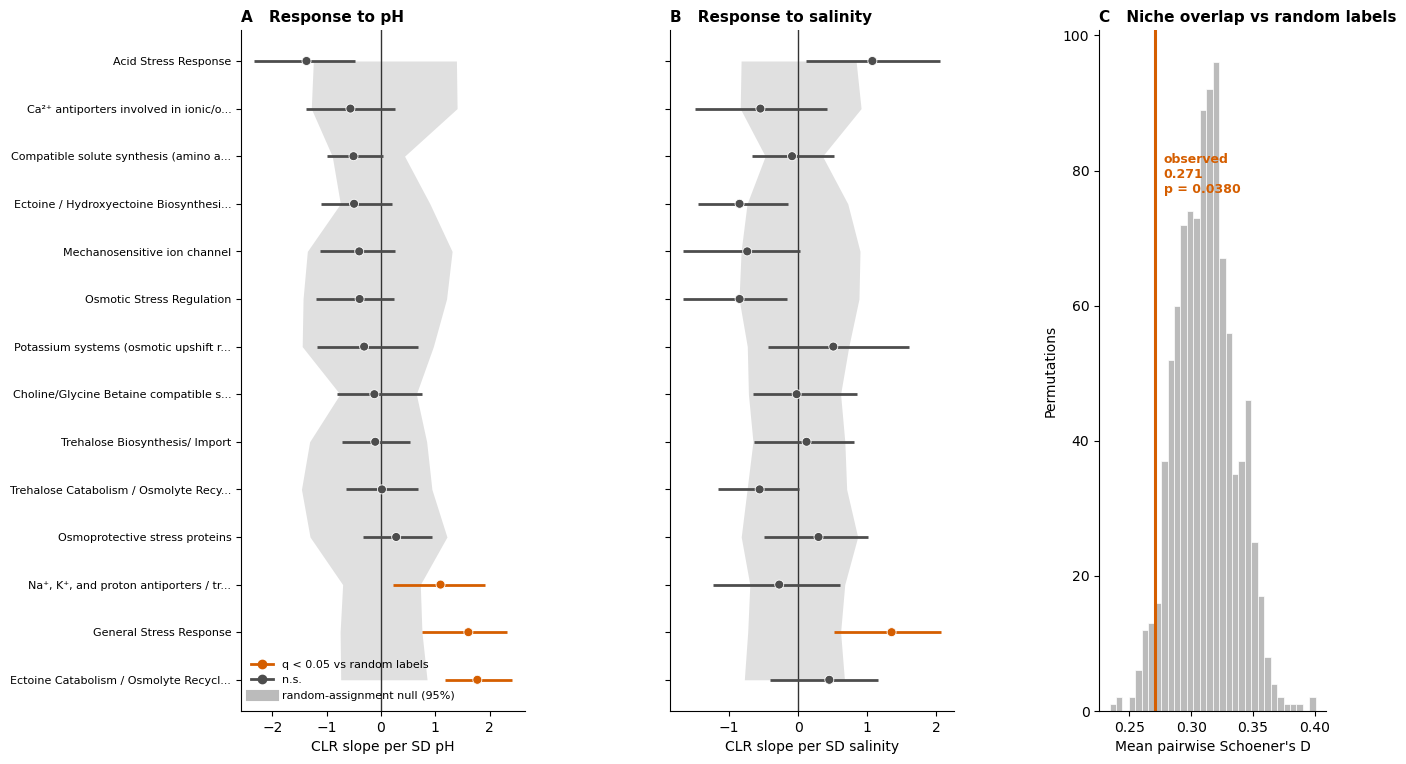

In [34]:
from matplotlib.lines import Line2D

plot_df = res[res["Category"].isin(REPORT_CATS)].copy()
ncp = nc.set_index("Category")
order = plot_df.sort_values("beta_pH")["Category"].tolist()
y = np.arange(len(order))
wrap = lambda s: s if len(s) <= 38 else s[:36] + "..."

fig = plt.figure(figsize=(14, max(4.5, 0.46 * len(order) + 2.4)))
gs = fig.add_gridspec(1, 3, width_ratios=[1, 1, 0.8], wspace=0.55)
axes = [fig.add_subplot(gs[0, i]) for i in range(3)]

for ax, (bcol, lo, hi, nlo, nhi, qcol, ttl, xl) in zip(axes[:2],
    [("beta_pH", "pH_lo", "pH_hi", "null_pH_lo", "null_pH_hi", "q_perm_pH",
      "A   Response to pH", "CLR slope per SD pH"),
     ("beta_sal", "sal_lo", "sal_hi", "null_sal_lo", "null_sal_hi", "q_perm_sal",
      "B   Response to salinity", "CLR slope per SD salinity")]):
    d = plot_df.set_index("Category").loc[order]
    n = ncp.loc[order]
    ax.fill_betweenx(y, n[nlo].values, n[nhi].values, color="#BBBBBB", alpha=0.45, lw=0, zorder=1)
    cols = np.where(n[qcol].values < 0.05, "#D55E00", "#4D4D4D")
    ax.hlines(y, d[lo].values, d[hi].values, color=cols, lw=2.0, zorder=3)
    ax.scatter(d[bcol].values, y, s=42, c=cols, zorder=4, edgecolor="white", linewidth=0.6)
    ax.axvline(0, color="#333333", lw=1.0, zorder=2)
    ax.set_yticks(y); ax.set_yticklabels([wrap(o) for o in order], fontsize=8)
    ax.set_xlabel(xl); ax.set_title(ttl, fontsize=11, fontweight="bold", loc="left")
    ax.invert_yaxis()
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
axes[1].set_yticklabels([])
axes[0].legend(handles=[
    Line2D([], [], color="#D55E00", lw=2, marker="o", ms=6, label="q < 0.05 vs random labels"),
    Line2D([], [], color="#4D4D4D", lw=2, marker="o", ms=6, label="n.s."),
    Line2D([], [], color="#BBBBBB", lw=8, label="random-assignment null (95%)")],
    loc="lower left", frameon=False, fontsize=8)

ax = axes[2]
ax.hist(null_meanD, bins=32, color="#BBBBBB", edgecolor="white", linewidth=0.5)
ax.axvline(mean_D_obs, color="#D55E00", lw=2.2)
ax.annotate(f"observed\n{mean_D_obs:.3f}\np = {p_D:.4f}",
            xy=(mean_D_obs, ax.get_ylim()[1] * 0.82), xytext=(6, 0),
            textcoords="offset points", color="#D55E00", fontsize=9,
            fontweight="bold", va="top")
ax.set_xlabel("Mean pairwise Schoener's D"); ax.set_ylabel("Permutations")
ax.set_title("C   Niche overlap vs random labels", fontsize=11, fontweight="bold", loc="left")
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)




In [28]:
#Figures

In [29]:
def panel_table(xlsx, col, flt=None):
    t = read_sheet(xlsx)
    if flt is not None:
        t = t[t[flt[0]].astype(str).str.strip() == flt[1]]
    if col not in t.columns:
        raise KeyError(f"'{col}' not in {os.path.basename(xlsx)}: {list(t.columns)}")

    v = t[col].dropna().astype(str).str.strip()
    dup = v.groupby(v.str.lower()).nunique()
    for k in dup[dup > 1].index:
        print(f"  case variants in {col}: {sorted(v[v.str.lower() == k].unique())}")

    t["_key"] = norm_key(t["annotation_description"])
    m = (t[["_key", col]].dropna(subset=[col]).drop_duplicates("_key")
           .rename(columns={col: "_cat"}))

    ac = t[col].dropna().value_counts()
    ann = (100 * ac / ac.sum()).rename("pct").to_frame().assign(n=ac)

    g = genes[["seq_name", "annotation_description"]].copy()
    g["_key"] = norm_key(g["annotation_description"])
    g = g.merge(m, on="_key", how="left").dropna(subset=["_cat"])
    assert len(g), f"no annotation matched {os.path.basename(xlsx)}"

    gc = g["_cat"].value_counts()
    gene_tab = (100 * gc / gc.sum()).rename("pct").to_frame().assign(n=gc)

    w = contig_lake.sum(axis=1)
    g["_w"] = g["seq_name"].map(w).fillna(0.0)
    rc = g.groupby("_cat")["_w"].sum()
    rpkm_tab = (100 * rc / rc.sum()).rename("pct").to_frame().assign(n=gc.reindex(rc.index))

    for d_ in (ann, gene_tab, rpkm_tab):
        d_.index.name = col
    print(f"{os.path.basename(xlsx)} [{col}]: {len(m):,} annotations, {len(g):,} genes")
    return ann, gene_tab, rpkm_tab

def compare(name, ann, gene_tab, rpkm_tab):
    j = (ann[["pct"]].rename(columns={"pct": "annotations_%"})
           .join(gene_tab[["pct", "n"]].rename(columns={"pct": "genes_%", "n": "n_genes"}), how="outer")
           .join(rpkm_tab[["pct"]].rename(columns={"pct": "rpkm_%"}), how="outer")
           .sort_values("genes_%", ascending=False))
    print(f"\n===== {name} =====")
    display(j.round(2))
    return j

annA, genA, rpkA = panel_table(FIG_A_XLSX, FIG_A_COL, FIG_A_FILTER)
cmpA = compare("A - functional categories", annA, genA, rpkA)
annB, genB, rpkB = panel_table(FIG_B_XLSX, FIG_B_COL, FIG_B_FILTER)
cmpB = compare("B - stress response categories", annB, genB, rpkB)
annC, genC, rpkC = panel_table(FIG_C_XLSX, FIG_C_COL, FIG_C_FILTER)
cmpC = compare("C - osmotic subcategories", annC, genC, rpkC)

for nm, c in [("A", cmpA), ("B", cmpB), ("C", cmpC)]:
    c.to_csv(f"{OUTDIR}/Fig6{nm}_composition_all_units.csv")

unique_annotation_descriptions_combined_wet_dry_plasmid_df_classified.xlsx [Category_3]: 955 annotations, 11,796 genes

===== A - functional categories =====


,annotations_%,genes_%,n_genes,rpkm_%
Category_3,,,,
Regulatory Function,12.59,14.67,1730,14.05
Stress Response,12.90,14.43,1702,15.92
Cell Envelope Maintenance,15.07,10.42,1229,13.18
Phosphorus Cycling,15.79,10.28,1213,8.99
Phosphonate Metabolism,1.75,9.44,1113,8.35
Carbon Cycling,9.39,8.30,979,9.46
Nitrogen cycling/metabolism,5.37,6.10,719,5.20
Aerobic Respiration (Etc),3.72,5.42,639,5.21
Sulfur Cycling,6.40,5.07,598,4.47


stress_classification.xlsx [Category_3]: 53 annotations, 867 genes

===== B - stress response categories =====


,annotations_%,genes_%,n_genes,rpkm_%
Category_3,,,,
Osmotic Stress Response,77.36,81.08,703,74.07
General Stress Response,20.75,15.80,137,20.28
Acid Stress Response,1.89,3.11,27,5.65


stress_classification.xlsx [Category]: 41 annotations, 703 genes

===== C - osmotic subcategories =====


,annotations_%,genes_%,n_genes,rpkm_%
Category,,,,
Choline/Glycine Betaine compatible solute regulation,2.44,31.29,220,31.31
"Na⁺, K⁺, and proton antiporters / transporters (ion homeostasis)",43.90,23.19,163,25.62
Ectoine Catabolism / Osmolyte Recycling,7.32,18.07,127,16.32
Ectoine / Hydroxyectoine Biosynthesis/ Import,9.76,14.65,103,15.48
Ca²⁺ antiporters involved in ionic/osmotic balance,7.32,3.41,24,3.20
Mechanosensitive ion channel,4.88,2.56,18,2.00
Osmotic Stress Regulation,4.88,2.56,18,1.61
Osmoprotective stress proteins,4.88,1.71,12,1.40
Potassium systems (osmotic upshift responders),4.88,1.00,7,0.83


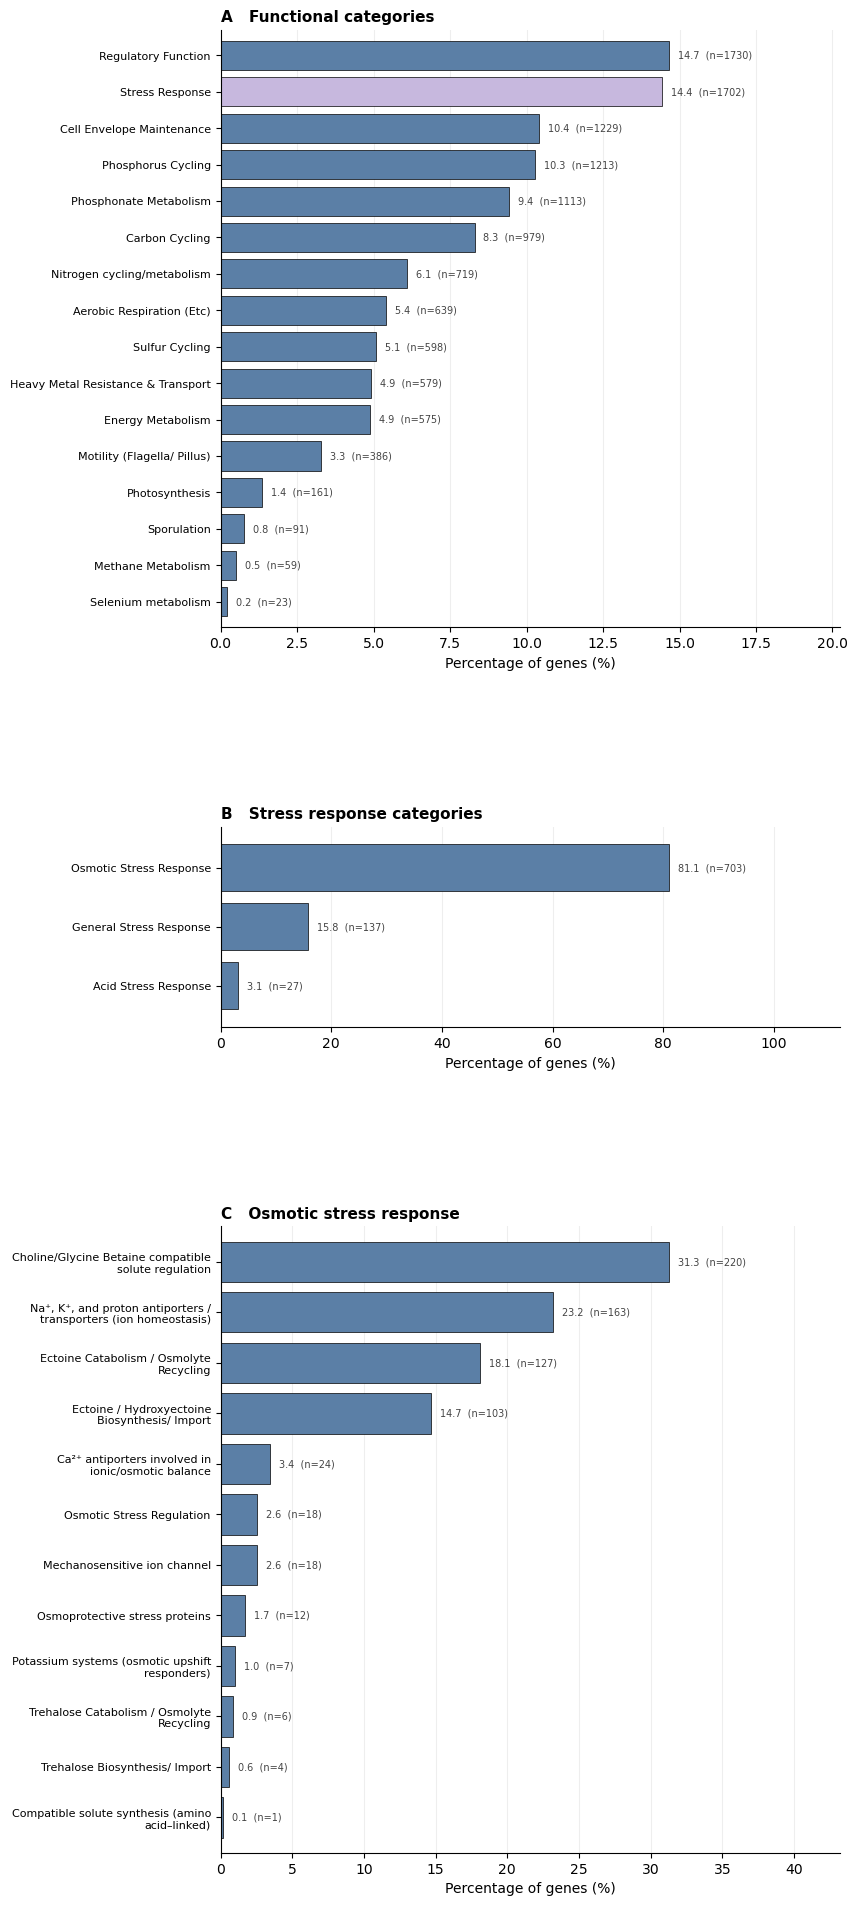

In [30]:
import textwrap

LABEL_WRAP = 34          # characters before a category name wraps

UNITS = {"genes": (genA, genB, genC, "Percentage of genes (%)"),
         "annotations": (annA, annB, annC, "Percentage of unique annotations (%)")}
A_tab, B_tab, C_tab, xlab = UNITS[PANEL_UNIT]

wrap_lab = lambda s: "\n".join(textwrap.wrap(str(s), LABEL_WRAP))

def barpanel(ax, tab, title, color="#5B7FA6", highlight=None, hl_color="#C7B8DE"):
    d = tab.sort_values("pct")
    cols = [hl_color if (highlight and highlight.lower() in str(i).lower()) else color
            for i in d.index]
    ax.barh(range(len(d)), d["pct"].values, color=cols, edgecolor="black",
            linewidth=0.5, zorder=2)
    ax.set_yticks(range(len(d)))
    ax.set_yticklabels([wrap_lab(i) for i in d.index], fontsize=8)
    for j, (v, n) in enumerate(zip(d["pct"].values, d["n"].values)):
        ax.text(v + d["pct"].max() * 0.02, j,
                f"{v:.1f}" + ("" if np.isnan(n) else f"  (n={int(n)})"),
                va="center", fontsize=7, color="#444444")
    ax.set_xlabel(xlab, fontsize=10)
    ax.set_xlim(0, d["pct"].max() * 1.38)
    ax.set_ylim(-0.7, len(d) - 0.3)
    ax.set_title(title, fontsize=11, fontweight="bold", loc="left")
    ax.grid(axis="x", color="#EEEEEE", lw=0.8, zorder=0)
    ax.set_axisbelow(True)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)

panels = [(A_tab, "A   Functional categories", "stress"),
          (B_tab, "B   Stress response categories", None),
          (C_tab, "C   Osmotic stress response", None)]

rows_needed = lambda t: sum(len(wrap_lab(i).split("\n")) for i in t.index)
hr = [0.26 * rows_needed(t) + 0.16 * len(t) + 1.5 for t, _, _ in panels]

fig, axes = plt.subplots(3, 1, figsize=(9.6, sum(hr)),
                         gridspec_kw={"height_ratios": hr})
for ax, (t, ttl, hl) in zip(axes, panels):
    barpanel(ax, t, ttl, highlight=hl)

fig.subplots_adjust(left=0.34, right=0.985, top=0.975, bottom=0.045, hspace=0.42)
fig.savefig(f"{OUTDIR}/Fig6ABC_composition_{PANEL_UNIT}.svg",
            bbox_inches="tight", pad_inches=0.2)
fig.savefig(f"{OUTDIR}/Fig6ABC_composition_{PANEL_UNIT}.png", dpi=400,
            bbox_inches="tight", pad_inches=0.2)
plt.show()

  27 genes |  3.24 eff. contigs | 30 lake-seasons | Acid Stress Response
 137 genes | 42.58 eff. contigs | 35 lake-seasons | General Stress Response
 103 genes | 45.15 eff. contigs | 44 lake-seasons | Ectoine / Hydroxyectoine Biosynthesis/ Import
 127 genes | 39.31 eff. contigs | 37 lake-seasons | Ectoine Catabolism / Osmolyte Recycling
   4 genes |  2.10 eff. contigs | 13 lake-seasons | Trehalose Biosynthesis/ Import
   6 genes |  1.74 eff. contigs | 15 lake-seasons | Trehalose Catabolism / Osmolyte Recycling

largest share plotted 0.511% exceeds BUBBLE_REF 0.5 - those bubbles draw larger than the legend maximum


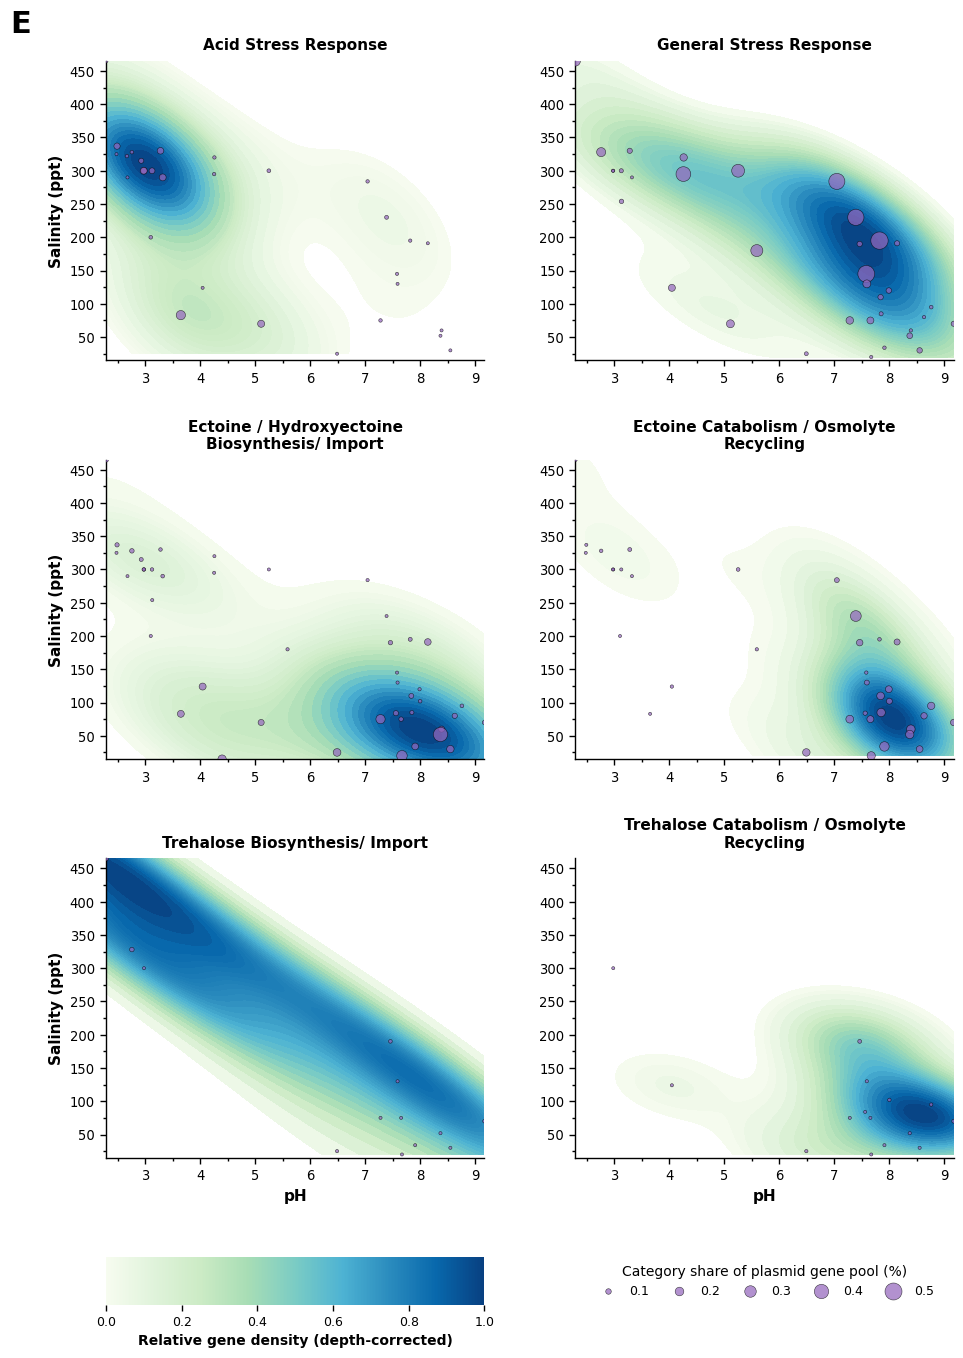

In [31]:
import math
import textwrap
import seaborn as sns
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator

SHOW_PANEL_N       = False
TITLE_WRAP         = 32
BUBBLE_LEGEND_VALS = np.arange(0.1, 0.51, 0.1)   
BUBBLE_REF         = 0.5                          

def resolve_cats(names):
    if names is None:
        return list(REPORT_CATS)
    out, bad = [], []
    for n in names:
        hit = [c for c in REPORT_CATS if n.lower() in c.lower()]
        if len(hit) > 1:
            exact = [c for c in hit if c.lower() == n.lower()]
            if len(exact) == 1:
                hit = exact
        if len(hit) == 1:
            out.append(hit[0])
        else:
            bad.append((n, hit))
    for n, hit in bad:
        print(f"skipped '{n}': matched {hit or 'nothing'}")
    if bad and not out:
        raise KeyError(f"no fragment resolved; available: {REPORT_CATS}")
    return out

def nice_steps(vmax, n=4):
    raw = vmax / n
    mag = 10 ** math.floor(math.log10(raw))
    step = next(m * mag for m in (1, 2, 2.5, 5, 10) if raw <= m * mag)
    v = np.arange(step, vmax + step * 0.5, step)
    v = v[v <= vmax][:n]
    d = 0
    while d < 4 and not np.allclose(np.round(v, d), v):
        d += 1
    return v, d

show_cats = resolve_cats(KDE_PANEL_CATS)
for c in show_cats:
    print(f"{qc.loc[c,'n_genes']:>4d} genes | {qc.loc[c,'eff_contigs']:>5.2f} eff. contigs | "
          f"{qc.loc[c,'n_lakes']:>2d} lake-seasons | {c}")

pH_lo, pH_hi = env["pH"].min(), env["pH"].max()
sa_lo, sa_hi = env["Salinity"].min(), env["Salinity"].max()
obs_max = (100 * P.loc[show_cats]).values.max()
gmax = BUBBLE_REF if BUBBLE_REF else obs_max
bubble = lambda v: BUBBLE_MIN + (BUBBLE_MAX - BUBBLE_MIN) * (np.asarray(v) / gmax) ** BUBBLE_GAMMA
if BUBBLE_REF and obs_max > BUBBLE_REF:
    print(f"\nlargest share plotted {obs_max:.3f}% exceeds BUBBLE_REF {BUBBLE_REF} "
          "- those bubbles draw larger than the legend maximum")

nrow = int(np.ceil(len(show_cats) / NCOL))
fig = plt.figure(figsize=(4.9 * NCOL, 4.1 * nrow + 1.6))
gs = GridSpec(nrow + 1, NCOL, figure=fig, height_ratios=[1] * nrow + [0.16],
              hspace=0.42, wspace=0.24, left=0.11, right=0.975, top=0.955, bottom=0.06)

for k, cat in enumerate(show_cats):
    ax = fig.add_subplot(gs[k // NCOL, k % NCOL])
    d = pd.DataFrame({"pH": env["pH"], "Salinity": env["Salinity"],
                      "w": P.loc[cat]}).query("w > 0")
    try:
        sns.kdeplot(data=d, x="pH", y="Salinity", weights=d["w"], fill=True, levels=30,
                    thresh=0.04, cmap="GnBu", bw_adjust=1.0, gridsize=200, cut=0, ax=ax)
    except Exception:
        pass
    ax.scatter(d["pH"], d["Salinity"], s=bubble(100 * d["w"]),
               color="#9467BD", alpha=0.72, edgecolor="black", linewidths=0.4, zorder=5)

    ax.set_xlim(pH_lo, pH_hi)
    ax.set_ylim(sa_lo, sa_hi)
    ax.set_title("\n".join(textwrap.wrap(KDE_TITLES.get(cat, cat), TITLE_WRAP)),
                 fontsize=11, fontweight="bold", pad=8)
    ax.set_xlabel("pH" if k // NCOL == nrow - 1 else "", fontsize=11, fontweight="bold")
    ax.set_ylabel("Salinity (ppt)" if k % NCOL == 0 else "", fontsize=11, fontweight="bold")
    if SHOW_PANEL_N:
        ax.text(0.02, 0.97, f"{int(qc.loc[cat,'n_genes'])} genes, "
                            f"{qc.loc[cat,'eff_contigs']:.1f} eff. contigs, "
                            f"{len(d)}/{len(env)} lake-seasons",
                transform=ax.transAxes, va="top", fontsize=7.5, color="#666666")

    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(direction="out", which="both", top=False, right=False,
                   labelsize=9.5, width=1.0, length=4.5)
    ax.tick_params(which="minor", length=2.5)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.0)

cax = fig.add_subplot(gs[nrow, 0])
sm_ = mpl.cm.ScalarMappable(cmap="GnBu", norm=mpl.colors.Normalize(0, 1)); sm_.set_array([])
cb = fig.colorbar(sm_, cax=cax, orientation="horizontal")
cb.set_label("Relative gene density (depth-corrected)", fontsize=10, fontweight="bold")
cb.ax.tick_params(labelsize=9, direction="out", width=1.0, length=4)
cb.outline.set_visible(False)

lax = fig.add_subplot(gs[nrow, 1]); lax.axis("off")
if BUBBLE_LEGEND_VALS is not None:
    vals, dec = np.asarray(BUBBLE_LEGEND_VALS), 1
else:
    vals, dec = nice_steps(gmax)
lax.legend([plt.scatter([], [], s=bubble(v), color="#9467BD", alpha=0.72,
                        edgecolor="black", linewidths=0.4) for v in vals],
           [f"{v:.{dec}f}" for v in vals],
           title="Category share of plasmid gene pool (%)",
           loc="center", frameon=False, ncol=len(vals),
           handletextpad=0.7, columnspacing=1.4, fontsize=9, title_fontsize=10)

fig.text(0.012, 0.992, "E", fontsize=22, fontweight="bold", va="top", ha="left")
fig.savefig(f"{OUTDIR}/Fig6E_kde_depthcorrected.svg", bbox_inches="tight", pad_inches=0.25)
fig.savefig(f"{OUTDIR}/Fig6E_kde_depthcorrected.png", dpi=400,
            bbox_inches="tight", pad_inches=0.25)
plt.show()

  27 genes |  3.24 eff. contigs | 30 lake-seasons | Acid Stress Response
  24 genes | 10.85 eff. contigs | 28 lake-seasons | Ca²⁺ antiporters involved in ionic/osmotic balance
 220 genes | 42.55 eff. contigs | 44 lake-seasons | Choline/Glycine Betaine compatible solute regulation
   1 genes |  1.00 eff. contigs |  2 lake-seasons | Compatible solute synthesis (amino acid–linked)
 103 genes | 45.15 eff. contigs | 44 lake-seasons | Ectoine / Hydroxyectoine Biosynthesis/ Import
 127 genes | 39.31 eff. contigs | 37 lake-seasons | Ectoine Catabolism / Osmolyte Recycling
 137 genes | 42.58 eff. contigs | 35 lake-seasons | General Stress Response
  18 genes |  7.22 eff. contigs | 17 lake-seasons | Mechanosensitive ion channel
 163 genes | 62.30 eff. contigs | 34 lake-seasons | Na⁺, K⁺, and proton antiporters / transporters (ion homeostasis)
  12 genes |  4.60 eff. contigs | 17 lake-seasons | Osmoprotective stress proteins
  18 genes |  8.37 eff. contigs | 22 lake-seasons | Osmotic Stress Regul

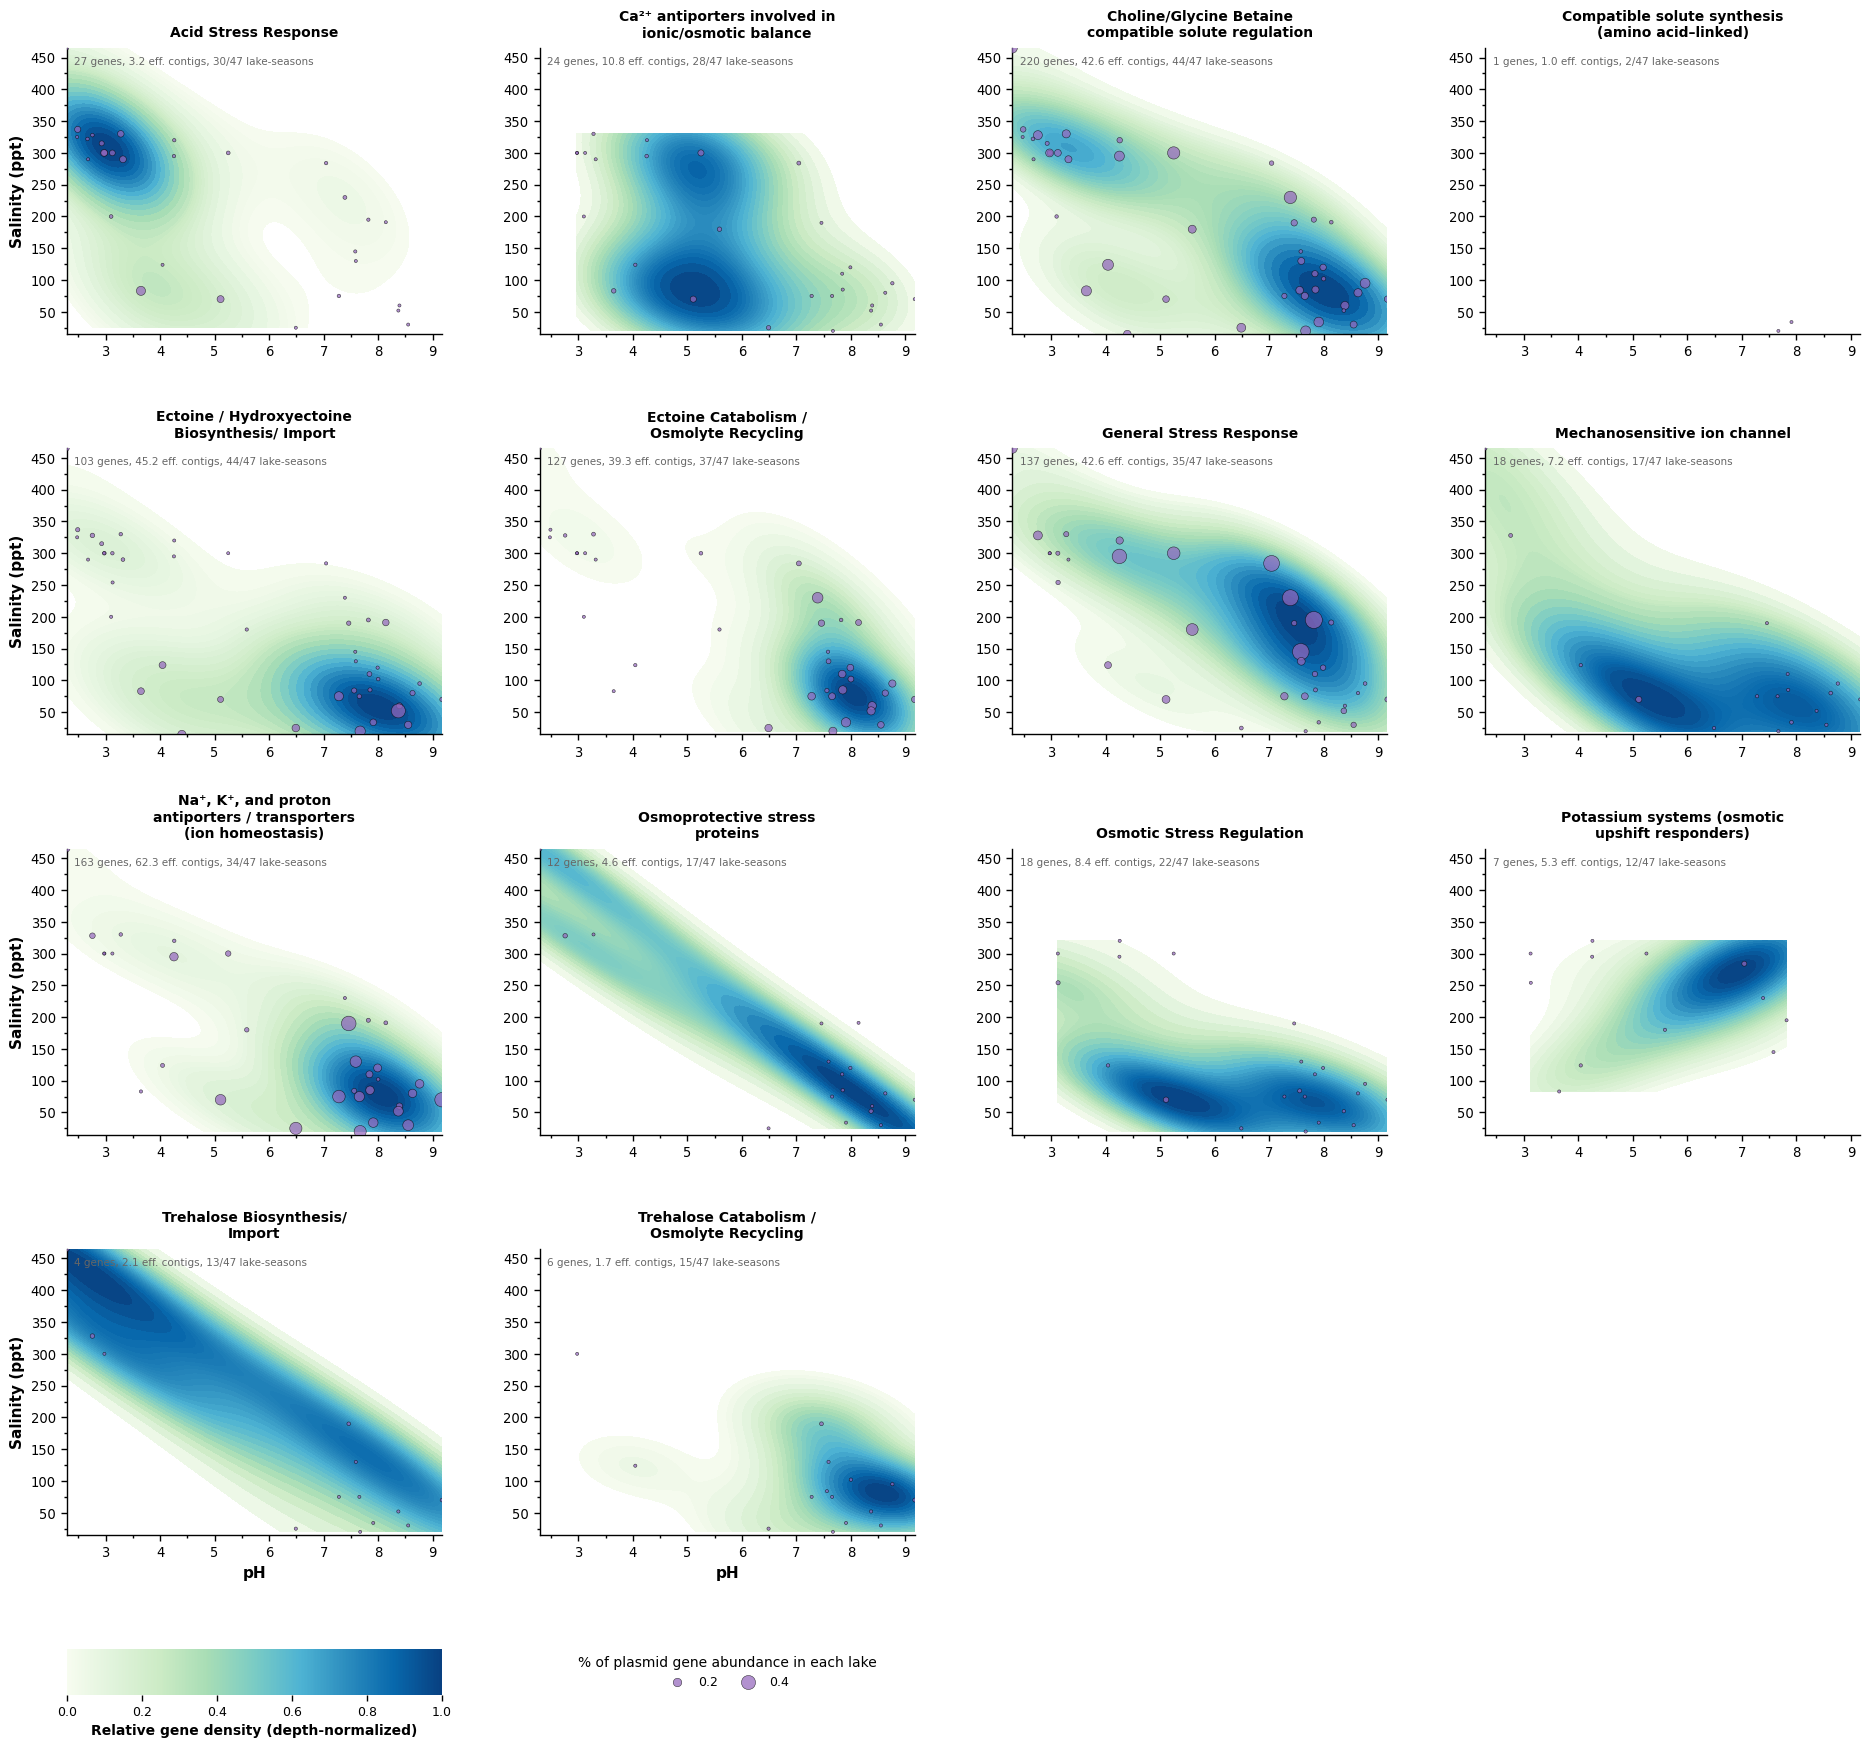

In [32]:
import math
import textwrap
import seaborn as sns
import matplotlib as mpl
from matplotlib.gridspec import GridSpec
from matplotlib.ticker import AutoMinorLocator

KDE_PANEL_CATS     = None      # None = every reported category
NCOL               = 4
SHOW_PANEL_N       = True      # gene / effective-contig / lake-season counts per panel
TITLE_WRAP         = 28
BUBBLE_LEGEND_VALS = None      
BUBBLE_REF         = None     

def resolve_cats(names):
    if names is None:
        return list(REPORT_CATS)
    out, bad = [], []
    for n in names:
        hit = [c for c in REPORT_CATS if n.lower() in c.lower()]
        if len(hit) > 1:
            exact = [c for c in hit if c.lower() == n.lower()]
            if len(exact) == 1:
                hit = exact
        if len(hit) == 1:
            out.append(hit[0])
        else:
            bad.append((n, hit))
    for n, hit in bad:
        print(f"skipped '{n}': matched {hit or 'nothing'}")
    if bad and not out:
        raise KeyError(f"no fragment resolved; available: {REPORT_CATS}")
    return out

def nice_steps(vmax, n=4):
    raw = vmax / n
    mag = 10 ** math.floor(math.log10(raw))
    step = next(m * mag for m in (1, 2, 2.5, 5, 10) if raw <= m * mag)
    v = np.arange(step, vmax + step * 0.5, step)
    v = v[v <= vmax][:n]
    d = 0
    while d < 4 and not np.allclose(np.round(v, d), v):
        d += 1
    return v, d

show_cats = resolve_cats(KDE_PANEL_CATS)
for c in show_cats:
    print(f"{qc.loc[c,'n_genes']:>4d} genes | {qc.loc[c,'eff_contigs']:>5.2f} eff. contigs | "
          f"{qc.loc[c,'n_lakes']:>2d} lake-seasons | {c}")

pH_lo, pH_hi = env["pH"].min(), env["pH"].max()
sa_lo, sa_hi = env["Salinity"].min(), env["Salinity"].max()
obs_max = (100 * P.loc[show_cats]).values.max()
gmax = BUBBLE_REF if BUBBLE_REF else obs_max
bubble = lambda v: BUBBLE_MIN + (BUBBLE_MAX - BUBBLE_MIN) * (np.asarray(v) / gmax) ** BUBBLE_GAMMA
if BUBBLE_REF and obs_max > BUBBLE_REF:
    print(f"\nlargest share plotted {obs_max:.3f}% exceeds BUBBLE_REF {BUBBLE_REF} "
          "- those bubbles draw larger than the legend maximum")

nrow = int(np.ceil(len(show_cats) / NCOL))
fig = plt.figure(figsize=(4.9 * NCOL, 4.1 * nrow + 1.6))
gs = GridSpec(nrow + 1, NCOL, figure=fig, height_ratios=[1] * nrow + [0.16],
              hspace=0.48, wspace=0.26, left=0.07, right=0.985, top=0.965, bottom=0.05)

for k, cat in enumerate(show_cats):
    ax = fig.add_subplot(gs[k // NCOL, k % NCOL])
    d = pd.DataFrame({"pH": env["pH"], "Salinity": env["Salinity"],
                      "w": P.loc[cat]}).query("w > 0")
    try:
        sns.kdeplot(data=d, x="pH", y="Salinity", weights=d["w"], fill=True, levels=30,
                    thresh=0.04, cmap="GnBu", bw_adjust=1.0, gridsize=200, cut=0, ax=ax)
    except Exception:
        pass
    ax.scatter(d["pH"], d["Salinity"], s=bubble(100 * d["w"]),
               color="#9467BD", alpha=0.72, edgecolor="black", linewidths=0.4, zorder=5)

    ax.set_xlim(pH_lo, pH_hi)
    ax.set_ylim(sa_lo, sa_hi)
    ax.set_title("\n".join(textwrap.wrap(KDE_TITLES.get(cat, cat), TITLE_WRAP)),
                 fontsize=10, fontweight="bold", pad=8)
    ax.set_xlabel("pH" if k // NCOL == nrow - 1 else "", fontsize=11, fontweight="bold")
    ax.set_ylabel("Salinity (ppt)" if k % NCOL == 0 else "", fontsize=11, fontweight="bold")
    if SHOW_PANEL_N:
        ax.text(0.02, 0.97, f"{int(qc.loc[cat,'n_genes'])} genes, "
                            f"{qc.loc[cat,'eff_contigs']:.1f} eff. contigs, "
                            f"{len(d)}/{len(env)} lake-seasons",
                transform=ax.transAxes, va="top", fontsize=7.5, color="#666666")

    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(direction="out", which="both", top=False, right=False,
                   labelsize=9.5, width=1.0, length=4.5)
    ax.tick_params(which="minor", length=2.5)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_visible(True)
        ax.spines[side].set_linewidth(1.0)

for k in range(len(show_cats), nrow * NCOL):
    fig.add_subplot(gs[k // NCOL, k % NCOL]).axis("off")

cax = fig.add_subplot(gs[nrow, 0])
sm_ = mpl.cm.ScalarMappable(cmap="GnBu", norm=mpl.colors.Normalize(0, 1)); sm_.set_array([])
cb = fig.colorbar(sm_, cax=cax, orientation="horizontal")
cb.set_label("Relative gene density (depth-normalized)", fontsize=10, fontweight="bold")
cb.ax.tick_params(labelsize=9, direction="out", width=1.0, length=4)
cb.outline.set_visible(False)

lax = fig.add_subplot(gs[nrow, 1]); lax.axis("off")
if BUBBLE_LEGEND_VALS is not None:
    vals, dec = np.asarray(BUBBLE_LEGEND_VALS), 1
else:
    vals, dec = nice_steps(gmax)
lax.legend([plt.scatter([], [], s=bubble(v), color="#9467BD", alpha=0.72,
                        edgecolor="black", linewidths=0.4) for v in vals],
           [f"{v:.{dec}f}" for v in vals],
           title="% of plasmid gene abundance in each lake",
           loc="center", frameon=False, ncol=len(vals),
           handletextpad=0.7, columnspacing=1.4, fontsize=9, title_fontsize=10)

fig.savefig(f"{OUTDIR}/FigS_kde_all_categories.svg", bbox_inches="tight", pad_inches=0.25)
fig.savefig(f"{OUTDIR}/FigS_kde_all_categories.png", dpi=400,
            bbox_inches="tight", pad_inches=0.25)
plt.show()

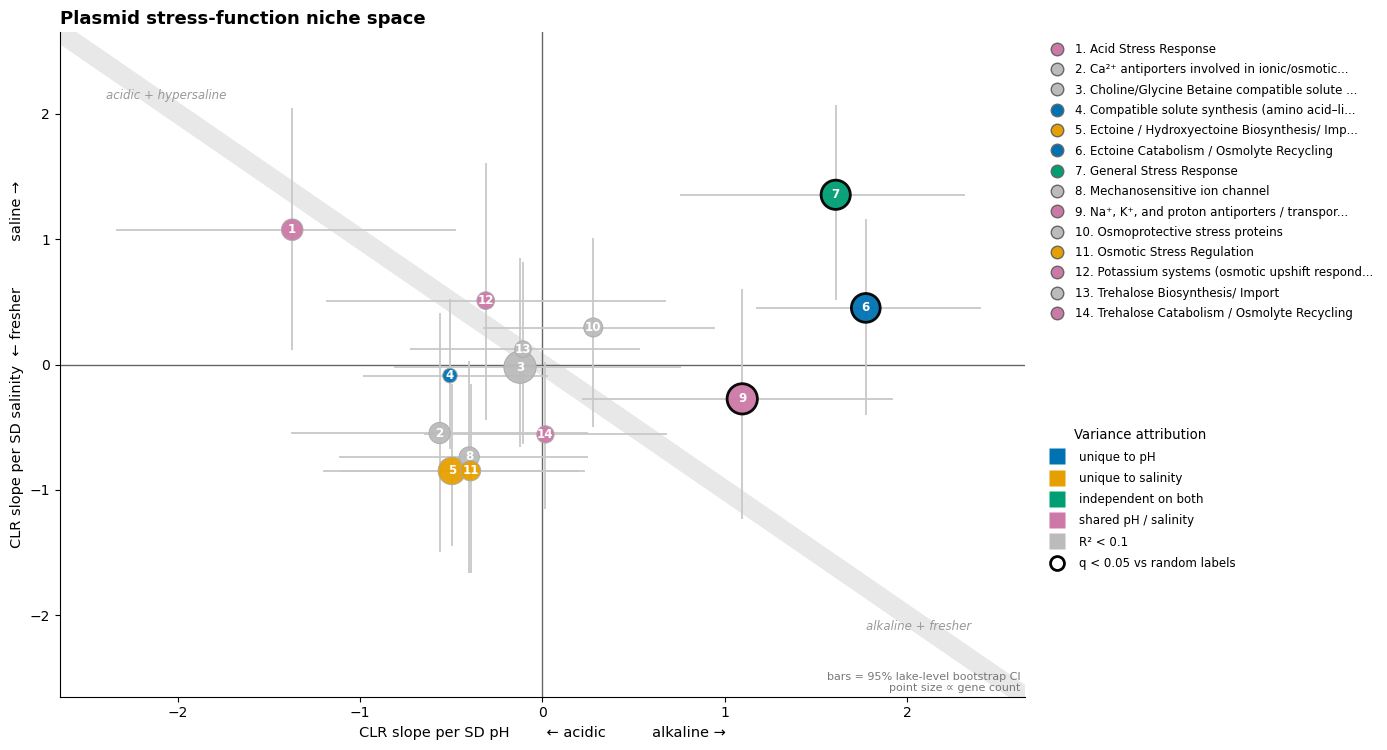

In [33]:
from matplotlib.lines import Line2D

ATTR = {"pH":       ("#0072B2", "unique to pH"),
        "salinity": ("#E69F00", "unique to salinity"),
        "both":     ("#009E73", "independent on both"),
        "shared":   ("#CC79A7", "shared pH / salinity"),
        "weak":     ("#BBBBBB", f"R\u00b2 < {R2_MIN}")}
cls = vp["attribution"]

r = res.set_index("Category").loc[REPORT_CATS]
n = nc.set_index("Category").loc[REPORT_CATS]
x, y = r["beta_pH"].values, r["beta_sal"].values
ng = qc["n_genes"].reindex(REPORT_CATS).values.astype(float)
sig = ((n["q_perm_pH"] < 0.05) | (n["q_perm_sal"] < 0.05)).values
sizes = 80 + 460 * np.sqrt(ng / ng.max())
cols = [ATTR[cls[c]][0] for c in REPORT_CATS]

fig, ax = plt.subplots(figsize=(12.6, 7.6))
lim = max(np.abs(np.r_[r["pH_lo"], r["pH_hi"], r["sal_lo"], r["sal_hi"]])) * 1.10
ax.plot([-lim, lim], [lim, -lim], color="#E8E8E8", lw=14, solid_capstyle="round", zorder=0)
ax.annotate("acidic + hypersaline", (-lim * 0.78, lim * 0.80), fontsize=8.5,
            color="#999999", ha="center", style="italic")
ax.annotate("alkaline + fresher", (lim * 0.78, -lim * 0.80), fontsize=8.5,
            color="#999999", ha="center", style="italic")
ax.axhline(0, color="#666666", lw=1.0, zorder=1)
ax.axvline(0, color="#666666", lw=1.0, zorder=1)
ax.errorbar(x, y, xerr=[x - r["pH_lo"], r["pH_hi"] - x],
            yerr=[y - r["sal_lo"], r["sal_hi"] - y],
            fmt="none", ecolor="#C8C8C8", lw=1.3, zorder=2)
ax.scatter(x, y, s=sizes, c=cols, edgecolor=np.where(sig, "black", "#AAAAAA"),
           linewidths=np.where(sig, 2.0, 0.7), zorder=4, alpha=0.95)
for i in range(len(REPORT_CATS)):
    ax.annotate(str(i + 1), (x[i], y[i]), ha="center", va="center", fontsize=8.5,
                fontweight="bold", color="white", zorder=7)

ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim)
ax.set_xlabel("CLR slope per SD pH        \u2190 acidic          alkaline \u2192", fontsize=10.5)
ax.set_ylabel("CLR slope per SD salinity  \u2190 fresher          saline \u2192", fontsize=10.5)
ax.set_title("Plasmid stress-function niche space", fontsize=13, fontweight="bold", loc="left")
for sp in ("top", "right"):
    ax.spines[sp].set_visible(False)

keyh = [Line2D([], [], marker="o", ls="", markerfacecolor=cols[i], markeredgecolor="#666666",
               markersize=9, label=f"{i+1}. " + (c if len(c) <= 44 else c[:42] + "..."))
        for i, c in enumerate(REPORT_CATS)]
leg1 = ax.legend(handles=keyh, loc="upper left", bbox_to_anchor=(1.01, 1.0),
                 frameon=False, fontsize=8.5, labelspacing=0.62, handletextpad=0.5)
ax.add_artist(leg1)
h = [Line2D([], [], marker="s", ls="", markerfacecolor=v[0], markeredgecolor="none",
            markersize=11, label=v[1]) for k, v in ATTR.items() if (cls == k).any()]
h += [Line2D([], [], marker="o", ls="", markerfacecolor="white", markeredgecolor="black",
             markeredgewidth=2, markersize=10, label="q < 0.05 vs random labels")]
ax.legend(handles=h, title="Variance attribution", loc="upper left",
          bbox_to_anchor=(1.01, 0.42), frameon=False, fontsize=8.5,
          title_fontsize=9.5, labelspacing=0.7)
ax.text(0.995, 0.005, "bars = 95% lake-level bootstrap CI\npoint size \u221d gene count",
        transform=ax.transAxes, ha="right", va="bottom", fontsize=8, color="#777777")

fig.tight_layout()
fig.savefig(f"{OUTDIR}/Fig6F_niche_space.svg", bbox_inches="tight")
fig.savefig(f"{OUTDIR}/Fig6F_niche_space.png", dpi=400, bbox_inches="tight")
plt.show()